In [ ]:
import torch
import gpytorch
import pandas as pd
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from torch.utils.data import TensorDataset, DataLoader
from pyproj import Transformer
from sklearn.metrics import pairwise_distances
from scipy.interpolate import RegularGridInterpolator
from torch_geometric.data import Data




In [ ]:
#read in dataset. 
with open('imputed_study_data.pkl', 'rb') as f:
    df=pickle.load(f)

In [ ]:
#convert to daily values 
df['date'] = df['time'].dt.tz_convert(None).dt.date
agg_cols = [
    'value',
    'temperature_2m','relative_humidity_2m','dew_point_2m',
    'wind_speed_10m','wind_direction_10m','surface_pressure','precipitation'
]
grouped = df.groupby(['location_id','station_lat','station_lon','date'], as_index=False)[agg_cols].mean()

grouped.head(5)

In [32]:
#new 
import math
import numpy as np
import networkx as nx
import pandas as pd

# (Keep your haversine_km, angle_diff_deg, and bearing_deg functions exactly as they are)

# Predictor columns to store as node feature vectors
predictor_cols = [
    'temperature_2m','relative_humidity_2m','dew_point_2m',
    'wind_speed_10m','wind_direction_10m','surface_pressure','precipitation'
]

# Build one directed graph per date and store in a dict
graphs = {}
# Parameters
DIST_THRESHOLD_KM = 5.0
SCORE_THRESHOLD = 0.0  # minimum score to create an edge
TOP_K = None  # set to an int to keep only top-K outgoing edges per node

for d in grouped['date'].unique():
    # Normalize key to ISO string (YYYY-MM-DD)
    date_key = d.isoformat() if hasattr(d, 'isoformat') else str(d)
    day = grouped[grouped['date'] == d].reset_index(drop=True)
    G = nx.DiGraph(date=date_key)

    # --- NEW STEP: CALCULATE REGIONAL BASELINE FOR THIS DAY ---
    # Extract all raw features for the current day's observed stations to find the spatial mean
    raw_day_feats = []
    for _, row in day.iterrows():
        feat = [float(row[col]) if col in row and not pd.isna(row[col]) else np.nan for col in predictor_cols]
        raw_day_feats.append(feat)
    
    # Compute the spatial baseline vector (ignoring NaNs seamlessly)
    # Shape: (len(predictor_cols),)
    regional_baseline = np.nanmean(np.array(raw_day_feats), axis=0)
    # ---------------------------------------------------------

    # Add nodes with transformed uniform-scale anomaly features
    for _, row in day.iterrows():
        loc = row['location_id']
        
        # 1. Gather raw feature vector
        raw_feat = np.array([float(row[col]) if col in row and not pd.isna(row[col]) else np.nan for col in predictor_cols], dtype=float)
        
        # 2. TRANSFORM TO ANOMALY: Subtract regional baseline (if not NaN)
        # Spatial deviations now replace absolute variables. 
        # (e.g., if raw temp is 22 and baseline is 20, the feature becomes +2.0)
        anomaly_feat = np.where(np.isnan(raw_feat) | np.isnan(regional_baseline), np.nan, raw_feat - regional_baseline)
        
        # 3. Append normalized geometry context (Lat, Lon) to the end of the feature vector
        # This keeps spatial coordinates explicitly structured for message passing
        final_feature_vector = np.append(anomaly_feat, [float(row['station_lat']), float(row['station_lon'])])

        G.add_node(loc,
                   station_lat=float(row['station_lat']),
                   station_lon=float(row['station_lon']),
                   wind_dir=float(row['wind_direction_10m']),
                   wind_speed=float(row['wind_speed_10m']),
                   features=final_feature_vector, # Saved as unified anomaly values + coords
                   feature_names=predictor_cols + ['lat_coord', 'lon_coord'])

    # Add directed edges between nodes <= DIST_THRESHOLD_KM using bearing-based scoring
    n = len(day)
    for i in range(n):
        ri = day.loc[i]
        src = ri['location_id']
        out_edges = []
        for j in range(n):
            if i == j:
                continue
            rj = day.loc[j]
            dist = haversine_km(float(ri['station_lat']), float(ri['station_lon']),
                                float(rj['station_lat']), float(rj['station_lon']))
            if dist <= DIST_THRESHOLD_KM:
                # Compute bearing from source -> target and compare with source wind direction
                bearing = bearing_deg(float(ri['station_lat']), float(ri['station_lon']),
                                       float(rj['station_lat']), float(rj['station_lon']))
                diff = angle_diff_deg(float(ri['wind_direction_10m']), bearing)
                sim_rad = math.radians(diff)
                # Score uses source wind speed multiplied by similarity between wind direction and bearing
                score = max(math.cos(sim_rad), 0.0) * float(ri['wind_speed_10m'])
                if score > SCORE_THRESHOLD:
                    out_edges.append((src, rj['location_id'], score, dist, diff))

        # Optionally keep only top-K outgoing edges
        if TOP_K is not None and len(out_edges) > 0:
            out_edges.sort(key=lambda x: x[2], reverse=True)
            out_edges = out_edges[:TOP_K]

        for src, tgt, score, dist, diff in out_edges:
            G.add_edge(src, tgt, weight=score, distance_km=dist, angle_diff_deg=diff)

    graphs[date_key] = G

In [35]:
import numpy as np

print("--- GRAPH DYNAMICS VERIFICATION ---")

# Track values for consecutive day comparisons
consecutive_dates = dates[:10]  # Look at the first 10 days as a sample

for i in range(len(consecutive_dates) - 1):
    d1, d2 = consecutive_dates[i], consecutive_dates[i+1]
    g1, g2 = graphs[d1], graphs[d2]
    
    # 1. Edge Sets
    edges1 = set(g1.edges())
    edges2 = set(g2.edges())
    
    # 2. Track weight variance for persistent edges
    shared_edges = edges1.intersection(edges2)
    weight_changes = []
    
    for u, v in shared_edges:
        w1 = g1[u][v]['weight']
        w2 = g2[u][v]['weight']
        weight_changes.append(abs(w1 - w2))
    
    # Calculate Jaccard Overlap for topology
    all_edges = edges1.union(edges2)
    jaccard = len(shared_edges) / len(all_edges) if all_edges else 1.0
    
    # Calculate mean weight shift for persistent paths
    mean_weight_shift = np.mean(weight_changes) if weight_changes else 0.0
    
    print(f"Shift from {d1} ➔ {d2}:")
    print(f"  • Total Edges      : Day1 = {g1.number_of_edges():<4} | Day2 = {g2.number_of_edges():<4}")
    print(f"  • Edge Jaccard     : {jaccard:.3f} (An overlap of 1.0 means static topology, closer to 0 means highly dynamic)")
    print(f"  • Mean Weight Shift: {mean_weight_shift:.4f} (Fluctuation in wind flux intensity for surviving edges)")
    print("-" * 50)

--- GRAPH DYNAMICS VERIFICATION ---
Shift from 2024-12-01 ➔ 2024-12-02:
  • Total Edges      : Day1 = 54   | Day2 = 55  
  • Edge Jaccard     : 0.198 (An overlap of 1.0 means static topology, closer to 0 means highly dynamic)
  • Mean Weight Shift: 4.3594 (Fluctuation in wind flux intensity for surviving edges)
--------------------------------------------------
Shift from 2024-12-02 ➔ 2024-12-03:
  • Total Edges      : Day1 = 55   | Day2 = 54  
  • Edge Jaccard     : 0.603 (An overlap of 1.0 means static topology, closer to 0 means highly dynamic)
  • Mean Weight Shift: 3.8107 (Fluctuation in wind flux intensity for surviving edges)
--------------------------------------------------
Shift from 2024-12-03 ➔ 2024-12-04:
  • Total Edges      : Day1 = 54   | Day2 = 54  
  • Edge Jaccard     : 0.800 (An overlap of 1.0 means static topology, closer to 0 means highly dynamic)
  • Mean Weight Shift: 2.1677 (Fluctuation in wind flux intensity for surviving edges)
-------------------------------

In [34]:
# Pick the first date and a random node key from your graph dict
sample_date = dates[0]
sample_graph = graphs[sample_date]
sample_node = list(sample_graph.nodes())[0]

# Retrieve attributes
node_data = sample_graph.nodes[sample_node]
feat_vector = node_data['features']
feat_names = node_data['feature_names']

print(f"--- Diagnostic Check for Date: {sample_date} | Node: {sample_node} ---")
for name, val in zip(feat_names, feat_vector):
    # Print out values formatted cleanly
    print(f"{name:<25} : {val:.4f}")

--- Diagnostic Check for Date: 2024-12-01 | Node: 2622586 ---
temperature_2m            : -0.5213
relative_humidity_2m      : 1.3381
dew_point_2m              : -0.3391
wind_speed_10m            : -2.3093
wind_direction_10m        : -4.5080
surface_pressure          : -8.4962
precipitation             : 0.0003
lat_coord                 : 37.5802
lon_coord                 : 127.0449


In [36]:
import base64
import folium
from folium import plugins
from IPython.display import HTML
from pathlib import Path

# select four dates from four separate months
selected_dates = []
seen_months = set()
for d in dates:
    month = d[:7]
    if month not in seen_months:
        selected_dates.append(d)
        seen_months.add(month)
    if len(selected_dates) == 4:
        break

if len(selected_dates) < 4:
    raise ValueError('Need at least 4 months of data to plot four separate panels.')

print('Selected dates:', selected_dates)

bbox = (126.8, 37.4, 127.1, 37.65)
min_lon, min_lat, max_lon, max_lat = bbox
center_lat = (min_lat + max_lat) / 2.0
center_lon = (min_lon + max_lon) / 2.0

def build_map_for_date(date_key):
    g = graphs[date_key]
    m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles='OpenStreetMap')
    folium.Rectangle(bounds=[[min_lat, min_lon], [max_lat, max_lon]], color='red', fill=False, weight=3).add_to(m)

    for node, data in g.nodes(data=True):
        folium.CircleMarker(
            location=[data['station_lat'], data['station_lon']],
            radius=5, color='black', fill=True, fill_color='cyan', fill_opacity=0.9,
            popup=str(node)
        ).add_to(m)

    for src, tgt, data in g.edges(data=True):
        udata = g.nodes[src]
        vdata = g.nodes[tgt]
        line = folium.PolyLine(
            locations=[
                [udata['station_lat'], udata['station_lon']],
                [vdata['station_lat'], vdata['station_lon']]
            ],
            color='blue',
            weight=max(1, min(6, data.get('weight', 0) / 2)),
            opacity=0.8,
        )
        line.add_to(m)
        
        # MODIFIED HERE: repeat=False and center=True ensures exactly one arrow in the middle
        plugins.PolyLineTextPath(
            line, '➤', repeat=False, center=True, offset=7, 
            attributes={'fill': 'blue', 'font-weight': 'bold', 'font-size': '14'}
        ).add_to(m)

    title_html = f'''<div style="position: fixed; top: 10px; left: 10px; z-index: 1000; background-color: white; padding: 6px; border: 1px solid grey; font-size: 14px;">{date_key}</div>'''
    m.get_root().html.add_child(folium.Element(title_html))
    return m

map_htmls = []
for date_key in selected_dates:
    m = build_map_for_date(date_key)
    
    # Render the map to raw HTML bytes
    map_raw_html = m._repr_html_()
    
    # Convert to a base64 string so it can safely load inside an iframe src without escaping issues
    b64_html = base64.b64encode(map_raw_html.encode('utf-8')).decode('utf-8')
    iframe_src = f"data:text/html;base64,{b64_html}"
    map_htmls.append(iframe_src)

# Build the panel grid using iframes
panel = '<div style="display:grid; grid-template-columns: repeat(2, 1fr); gap: 12px; width:100%;">'
for date_key, iframe_src in zip(selected_dates, map_htmls):
    panel += '<div style="border:1px solid #ccc; padding: 8px;">'
    panel += f'<h4 style="margin:0 0 8px 0; font-size: 16px;">{date_key}</h4>'
    # Use an iframe to safely isolate the Folium map instance
    panel += f'<iframe src="{iframe_src}" style="width:100%; height:450px; border:none;"></iframe>'
    panel += '</div>'
panel += '</div>'

display(HTML(panel))

Selected dates: ['2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01']


In [ ]:
#now, we standardize our observed nodes features by making a daily baseline feature vector, then
#we use this along with the observed nodes features to make the unit equal. 

#specifically, if the baseline for temperature on day 1 is 20, and my nodes value is 22, the temperature
#for node becomes 2 etc. 

In [27]:
#now extract a grid around the original region to sample values. 



import os
import time
import math
import random
import requests
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import timedelta, datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from pyproj import Transformer
from threading import Lock

# -------------------------
# User inputs (edit as needed)
# -------------------------
BBOX = (126.8, 37.4, 127.1, 37.65)   # (min_lon, min_lat, max_lon, max_lat)
lengthscale_km = 4.5                 # spatial lengthscale in km (used to set spacing if building grid)
spacing_km = lengthscale_km / 2.0
cell_size_m = spacing_km * 1000.0

# Try to use existing grid_centers or centers; otherwise build grid from BBOX
try:
    grid_centers  # noqa: F821
    use_existing_grid = True
except NameError:
    try:
        centers  # noqa: F821
        grid_centers = centers
        use_existing_grid = True
    except NameError:
        use_existing_grid = False

# -------------------------
# Open‑Meteo daily endpoint and variables (deduped)
# -------------------------
ARCHIVE_BASE = "https://archive-api.open-meteo.com/v1/archive"
daily_vars = [
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "dew_point_2m_mean",
    "windspeed_10m_mean",
    "winddirection_10m_dominant",
    "surface_pressure_mean",
    "precipitation_sum"
]
# ensure uniqueness while preserving order
_seen = set()
daily_vars = [x for x in daily_vars if not (x in _seen or _seen.add(x))]

timezone = "UTC"

# Date range (uses your provided last timestamp)
first_timestamp = pd.Timestamp('2024-12-01 00:00:00+0000', tz='UTC')
start_date = first_timestamp.tz_convert("UTC").date().isoformat()
last_timestamp = pd.Timestamp("2025-08-31 23:00:00+0000", tz="UTC")
end_date = last_timestamp.tz_convert("UTC").date().isoformat()

# Output and fetch settings (safer defaults)
out_dir = "open_meteo_grid_daily_direct"
os.makedirs(out_dir, exist_ok=True)
requests_per_second = 1.0   # safer default; increase only if you confirm API capacity
max_workers = 4            # lower concurrency to reduce bursts
max_retries = 5
retry_backoff_base = 2.0   # base for exponential backoff
max_backoff_seconds = 300  # cap backoff to 5 minutes

# -------------------------
# Build grid_centers if needed (square metric grid using AEQD projection)
# -------------------------
if not use_existing_grid:
    min_lon, min_lat, max_lon, max_lat = BBOX
    center_lon = (min_lon + max_lon) / 2.0
    center_lat = (min_lat + max_lat) / 2.0

    proj_str = f"+proj=aeqd +lat_0={center_lat} +lon_0={center_lon} +units=m +datum=WGS84 +no_defs"
    transformer_to_m = Transformer.from_crs("epsg:4326", proj_str, always_xy=True)
    transformer_to_lonlat = Transformer.from_crs(proj_str, "epsg:4326", always_xy=True)

    def lonlat_to_m(lon, lat):
        x, y = transformer_to_m.transform(lon, lat)
        return float(x), float(y)

    def m_to_lonlat(x, y):
        lon, lat = transformer_to_lonlat.transform(x, y)
        return float(lon), float(lat)

    x_min, y_min = lonlat_to_m(min_lon, min_lat)
    x_max, y_max = lonlat_to_m(max_lon, max_lat)
    x0, x1 = min(x_min, x_max), max(x_min, x_max)
    y0, y1 = min(y_min, y_max), max(y_min, y_max)

    n_cols = int(math.ceil((x1 - x0) / cell_size_m))
    n_rows = int(math.ceil((y1 - y0) / cell_size_m))
    grid_centers = []
    for i in range(n_cols):
        for j in range(n_rows):
            x_left = x0 + i * cell_size_m
            x_right = x0 + (i + 1) * cell_size_m
            y_bottom = y0 + j * cell_size_m
            y_top = y0 + (j + 1) * cell_size_m
            cx = (x_left + x_right) / 2.0
            cy = (y_bottom + y_top) / 2.0
            lonc, latc = m_to_lonlat(cx, cy)
            grid_centers.append((lonc, latc))
    print(f"Built grid: {n_cols} cols × {n_rows} rows = {len(grid_centers)} cells; spacing {spacing_km:.3f} km")
else:
    # normalize grid_centers formats
    if isinstance(grid_centers, np.ndarray):
        grid_centers = [tuple(x) for x in grid_centers.tolist()]
    elif isinstance(grid_centers, pd.DataFrame):
        if {'lon','lat'}.issubset(set(grid_centers.columns)):
            grid_centers = list(zip(grid_centers['lon'].values, grid_centers['lat'].values))
        else:
            raise RuntimeError("If grid_centers is a DataFrame it must contain 'lon' and 'lat' columns.")
    print(f"Using existing grid_centers with {len(grid_centers)} cells")

# Quick validation: ensure tuples are (lon, lat). If many entries look swapped, offer automatic swap.
def looks_like_latlon_swapped(sample):
    lon, lat = sample
    return abs(lon) <= 90 and abs(lat) <= 180 and not (-180 <= lon <= 180 and -90 <= lat <= 90)

if len(grid_centers) > 0:
    first = grid_centers[0]
    if looks_like_latlon_swapped(first):
        print("Detected grid_centers likely in (lat, lon) order; swapping to (lon, lat).")
        grid_centers = [(lonlat[1], lonlat[0]) for lonlat in grid_centers]

# -------------------------
# Helpers for daily fetch with retries, 429 handling, and caching
# -------------------------
def build_params_daily(lat, lon, start_iso, end_iso, daily_vars, timezone="UTC"):
    return {
        "latitude": float(lat),
        "longitude": float(lon),
        "start_date": start_iso,
        "end_date": end_iso,
        "daily": ",".join(daily_vars),
        "timezone": timezone
    }

SESSION = requests.Session()
RATE_LOCK = Lock()
LAST_REQUEST_TS = 0.0

def throttle():
    """Global pacing to respect requests_per_second across threads."""
    global LAST_REQUEST_TS
    with RATE_LOCK:
        min_interval = 1.0 / max(1.0, requests_per_second)
        now = time.time()
        wait = LAST_REQUEST_TS + min_interval - now
        if wait > 0:
            time.sleep(wait)
        LAST_REQUEST_TS = time.time()

def _sleep_with_jitter(seconds):
    """Sleep with small jitter to avoid synchronized retries."""
    jitter = random.uniform(0.0, 0.25 * seconds) if seconds > 0 else 0.0
    time.sleep(seconds + jitter)

def fetch_daily_with_retries(lat, lon, start_iso, end_iso, daily_vars, timezone="UTC"):
    params = build_params_daily(lat, lon, start_iso, end_iso, daily_vars, timezone)
    attempt = 0
    while attempt <= max_retries:
        try:
            throttle()
            r = SESSION.get(ARCHIVE_BASE, params=params, timeout=60)
            if r.status_code == 200:
                try:
                    return r.json()
                except ValueError:
                    raise RuntimeError(f"Invalid JSON response for ({lat},{lon})")
            elif r.status_code == 429:
                # Rate limited: honor Retry-After if present, otherwise exponential backoff
                retry_after = r.headers.get("Retry-After")
                if retry_after is not None:
                    try:
                        wait = float(retry_after)
                    except Exception:
                        # sometimes Retry-After is a HTTP-date; fallback to a safe wait
                        wait = min(60.0, retry_backoff_base ** (attempt + 1))
                    wait = min(wait, max_backoff_seconds)
                    print(f"429 for ({lat},{lon}) — server asked to wait {wait}s (Retry-After). Attempt {attempt+1}/{max_retries}")
                    _sleep_with_jitter(wait)
                else:
                    # exponential backoff with jitter
                    wait = min(max_backoff_seconds, retry_backoff_base ** (attempt + 1))
                    print(f"429 for ({lat},{lon}) — backing off {wait}s (no Retry-After). Attempt {attempt+1}/{max_retries}")
                    _sleep_with_jitter(wait)
                attempt += 1
                continue
            else:
                text = r.text[:1000] if r.text else ""
                print(f"API returned status {r.status_code} for ({lat},{lon}) start={start_iso} end={end_iso}: {text}")
                r.raise_for_status()
        except requests.RequestException as e:
            attempt += 1
            # exponential backoff with jitter for network errors
            wait = min(max_backoff_seconds, retry_backoff_base ** attempt)
            print(f"Network/request error for ({lat},{lon}) attempt {attempt}/{max_retries}: {e}. Backing off {wait}s")
            _sleep_with_jitter(wait)
            if attempt > max_retries:
                raise RuntimeError(f"Failed to fetch daily ({lat},{lon}) after {max_retries} retries: {e}")
        except Exception as e:
            attempt += 1
            wait = min(max_backoff_seconds, retry_backoff_base ** attempt)
            print(f"Unexpected error for ({lat},{lon}) attempt {attempt}/{max_retries}: {e}. Backing off {wait}s")
            _sleep_with_jitter(wait)
            if attempt > max_retries:
                raise RuntimeError(f"Failed to fetch daily ({lat},{lon}) after {max_retries} retries: {e}")
    raise RuntimeError("unreachable")

def safe_daily_path(cell_dir, idx):
    return os.path.join(cell_dir, f"cell_{idx:04d}_daily")

# -------------------------
# Parse daily payload into DataFrame (handles missing vars gracefully)
# -------------------------
def parse_daily_payload(payload, daily_vars):
    daily = payload.get("daily", {})
    times = daily.get("time", [])
    if len(times) == 0:
        return pd.DataFrame(columns=["date"] + daily_vars)
    try:
        df = pd.DataFrame({"date": pd.to_datetime(times)})
        for var in daily_vars:
            vals = daily.get(var)
            if vals is None:
                df[var] = np.nan
            else:
                df[var] = pd.to_numeric(vals, errors="coerce")
        df['date'] = pd.to_datetime(df['date']).dt.date
        return df
    except Exception as e:
        print("Failed to parse payload into DataFrame:", e)
        try:
            print("Payload daily keys:", list(daily.keys()))
            import json
            sample = {k: (daily.get(k)[:3] if isinstance(daily.get(k), list) else daily.get(k)) for k in list(daily.keys())[:10]}
            print(json.dumps(sample, default=str))
        except Exception:
            pass
        raise

# -------------------------
# Main: fetch full-range daily per cell (one request per cell), cache per-cell daily parquet/csv
# -------------------------
n_cells = len(grid_centers)
print(f"Fetching Open‑Meteo daily for {n_cells} cells from {start_date} to {end_date} (one request per cell)")

# pre-create date keys
start_dt = pd.to_datetime(start_date).date()
end_dt = pd.to_datetime(end_date).date()
all_dates = pd.date_range(start=start_dt, end=end_dt, freq="D").date.tolist()
data_by_day = {d.isoformat(): {} for d in all_dates}

def process_cell_daily(idx, lon, lat):
    cell_dir = os.path.join(out_dir, f"cell_{idx:04d}")
    os.makedirs(cell_dir, exist_ok=True)
    base_path = safe_daily_path(cell_dir, idx)
    parquet_path = base_path + ".parquet"
    csv_path = base_path + ".csv"

    # if cached parquet or csv exists, load and return
    if os.path.exists(parquet_path):
        try:
            df_cell = pd.read_parquet(parquet_path)
            if 'date' in df_cell.columns:
                df_cell['date'] = pd.to_datetime(df_cell['date']).dt.date
            return idx, lon, lat, df_cell
        except Exception as e:
            print(f"Warning: failed to read parquet for cell {idx}: {e}")

    if os.path.exists(csv_path):
        try:
            df_cell = pd.read_csv(csv_path, parse_dates=["date"])
            if 'date' in df_cell.columns:
                df_cell['date'] = pd.to_datetime(df_cell['date']).dt.date
            return idx, lon, lat, df_cell
        except Exception as e:
            print(f"Warning: failed to read csv for cell {idx}: {e}")

    # sanity check for coordinate ranges
    if not (-90.0 <= lat <= 90.0 and -180.0 <= lon <= 180.0):
        raise RuntimeError(f"Invalid coordinates for cell {idx}: lat={lat}, lon={lon}")

    # fetch daily range in one request (with robust retry/429 handling)
    payload = fetch_daily_with_retries(lat=lat, lon=lon, start_iso=start_date, end_iso=end_date, daily_vars=daily_vars, timezone=timezone)

    df_cell = parse_daily_payload(payload, daily_vars)

    # if API returned no rows, create full-range empty frame
    if df_cell.shape[0] == 0:
        df_cell = pd.DataFrame({"date": all_dates})
        for var in daily_vars:
            df_cell[var] = np.nan
    else:
        df_cell['date'] = pd.to_datetime(df_cell['date']).dt.date

    # -------------------------
    # Safe reindexing: avoid duplicate 'date' column
    # -------------------------
    if 'date' in df_cell.columns:
        temp_index = pd.to_datetime(df_cell['date'])
        df_cell = df_cell.drop(columns=['date'])
    else:
        temp_index = pd.to_datetime(df_cell.index)

    df_cell = df_cell.set_index(temp_index).reindex(pd.to_datetime(all_dates))
    df_cell.index.name = 'date'
    df_cell = df_cell.reset_index()
    df_cell['date'] = pd.to_datetime(df_cell['date']).dt.date

    # add lon/lat columns
    df_cell['lon'] = lon
    df_cell['lat'] = lat

    # try to save parquet, fallback to CSV
    try:
        df_cell.to_parquet(parquet_path, index=False)
    except Exception as e:
        try:
            df_cell.to_csv(csv_path, index=False)
        except Exception as e2:
            print(f"Failed to save cell {idx} to parquet and csv: {e2}")

    return idx, lon, lat, df_cell

# run cells in parallel (one request per cell)
with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = {ex.submit(process_cell_daily, idx, lon, lat): (idx, lon, lat) for idx, (lon, lat) in enumerate(grid_centers)}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Fetching cells"):
        idx, lon, lat = futures[fut]
        try:
            res_idx, res_lon, res_lat, df_cell = fut.result()
        except Exception as e:
            print(f"Cell {idx} failed: {e}")
            continue
        if df_cell is None or df_cell.shape[0] == 0:
            continue
        # populate data_by_day from df_cell
        for _, row in df_cell.iterrows():
            date_iso = pd.to_datetime(row['date']).date().isoformat()
            if date_iso not in data_by_day:
                continue
            entry = {'lon': float(res_lon), 'lat': float(res_lat)}
            for var in daily_vars:
                entry[var] = float(row[var]) if var in row and not pd.isna(row[var]) else np.nan
            data_by_day[date_iso][int(res_idx)] = entry

print("Done. Cached per-cell daily files are in:", out_dir)
print("Access daily predictors via data_by_day[date_iso][cell_idx] -> dict of daily features")



Built grid: 12 cols × 13 rows = 156 cells; spacing 2.250 km
Fetching Open‑Meteo daily for 156 cells from 2024-12-01 to 2025-08-31 (one request per cell)


Fetching cells: 100%|██████████| 156/156 [00:01<00:00, 88.97it/s] 

Done. Cached per-cell daily files are in: open_meteo_grid_daily_direct
Access daily predictors via data_by_day[date_iso][cell_idx] -> dict of daily features


In [59]:
#check that the gridded data is not significantly different from observed. 

# Map your graph's predictor names back to the open-meteo keys for alignment
graph_to_api_cols = {
    'temperature_2m': 'temperature_2m_mean',
    'relative_humidity_2m': 'relative_humidity_2m_mean',
    'dew_point_2m': 'dew_point_2m_mean',
    'wind_speed_10m': 'windspeed_10m_mean',
    'wind_direction_10m': 'winddirection_10m_dominant',
    'surface_pressure': 'surface_pressure_mean',
    'precipitation': 'precipitation_sum'
}

# --------------------------------------------------------------------
# STEP 1: FIND THE NEAREST GRID CELL FOR EACH PHYSICAL STATION
# --------------------------------------------------------------------
station_to_cell_mapping = {}
sample_date = dates[0]
grid_today = processed_grid_by_day[sample_date]

# Get unique physical stations and their coordinates
unique_stations = day_df[['location_id', 'station_lat', 'station_lon']].drop_duplicates()

for _, s_row in unique_stations.iterrows():
    s_id = s_row['location_id']
    s_lat, s_lon = s_row['station_lat'], s_row['station_lon']
    
    # Compute distances to all candidate grid cells to find the closest match
    best_dist = float('inf')
    closest_cell_idx = None
    
    for cell_idx, c_data in grid_today.items():
        dist = haversine_km(s_lat, s_lon, c_data['lat'], c_data['lon'])
        if dist < best_dist:
            best_dist = dist
            closest_cell_idx = cell_idx
            
    station_to_cell_mapping[s_id] = {
        'cell_idx': closest_cell_idx,
        'distance_km': best_dist
    }

# --------------------------------------------------------------------
# STEP 2: PAIR DAILY OBSERVED DATA WITH THE CLOSEST MODEL CELL
# --------------------------------------------------------------------
comparison_records = []

# Loop over your structured historical dataframe
for _, row in grouped.iterrows():
    date_iso = row['date'].isoformat() if hasattr(row['date'], 'isoformat') else str(row['date'])
    s_id = row['location_id']
    
    # Check if we have data for this date in both sets
    if date_iso not in processed_grid_by_day or s_id not in station_to_cell_mapping:
        continue
        
    cell_idx = station_to_cell_mapping[s_id]['cell_idx']
    cell_data = data_by_day[date_iso][cell_idx] # Grabbing raw api values before anomaly subtraction
    
    record = {
        'date': date_iso,
        'station_id': s_id,
        'distance_km': station_to_cell_mapping[s_id]['distance_km']
    }
    
    # Populate paired features
    for g_col, api_col in graph_to_api_cols.items():
        if g_col in row and api_col in cell_data:
            record[f'obs_{g_col}'] = float(row[g_col])
            record[f'mod_{g_col}'] = float(cell_data[api_col])
            
    comparison_records.append(record)

comp_df = pd.DataFrame(comparison_records)

# --------------------------------------------------------------------
# STEP 3: COMPUTE ERROR METRICS & GENERATE VALIDATION REPORT
# --------------------------------------------------------------------
print("=================== OPEN-METEO VS. SENSOR VALIDATION REPORT ===================")
print(f"Paired data samples analyzed: {len(comp_df)} station-days across the network.\n")
print(f"{'Weather Variable':<25} | {'Mean Obs':<10} | {'Mean Model':<10} | {'MAE':<8} | {'Bias (Mod-Obs)':<15}")
print("-" * 75)

for g_col in graph_to_api_cols.keys():
    obs_vals = comp_df[f'obs_{g_col}'].values
    mod_vals = comp_df[f'mod_{g_col}'].values
    
    # Drop any matching NaNs to ensure clean arrays
    mask = ~np.isnan(obs_vals) & ~np.isnan(mod_vals)
    if mask.sum() == 0:
        continue
        
    obs_clean = obs_vals[mask]
    mod_clean = mod_vals[mask]
    
    # Handle wind direction wrap-around (0 and 360 are identical)
    if g_col == 'wind_direction_10m':
        raw_diff = (mod_clean - obs_clean) % 360
        mae = np.mean(np.minimum(raw_diff, 360 - raw_diff))
        bias = np.mean(((mod_clean - obs_clean + 180) % 360) - 180) # Directional bias
    else:
        mae = np.mean(np.abs(mod_clean - obs_clean))
        bias = np.mean(mod_clean - obs_clean)
        
    print(f"{g_col:<25} | {np.mean(obs_clean):<10.2f} | {np.mean(mod_clean):<10.2f} | {mae:<8.2f} | {bias:<15.2f}")
print("===============================================================================")

=================== OPEN-METEO VS. SENSOR VALIDATION REPORT ===================
Paired data samples analyzed: 7124 station-days across the network.

Weather Variable          | Mean Obs   | Mean Model | MAE      | Bias (Mod-Obs) 
---------------------------------------------------------------------------
temperature_2m            | 11.86      | 11.87      | 0.74     | 0.01           
relative_humidity_2m      | 68.50      | 68.85      | 3.83     | 0.35           
dew_point_2m              | 5.61       | 5.71       | 1.05     | 0.11           
wind_speed_10m            | 7.73       | 7.82       | 1.18     | 0.09           
wind_direction_10m        | 211.49     | 226.68     | 31.76    | 12.62          
surface_pressure          | 1007.61    | 1009.80    | 5.71     | 2.19           
precipitation             | 0.13       | 3.06       | 2.94     | 2.93           


In [37]:
#standardizing the grid data to allow us to compare it with the observed nodes data. 

import numpy as np
import pandas as pd

# Map Open-Meteo API keys to your internal graph's predictor columns
api_to_graph_cols = {
    'temperature_2m_mean': 'temperature_2m',
    'relative_humidity_2m_mean': 'relative_humidity_2m',
    'dew_point_2m_mean': 'dew_point_2m',
    'windspeed_10m_mean': 'wind_speed_10m',
    'winddirection_10m_dominant': 'wind_direction_10m',
    'surface_pressure_mean': 'surface_pressure',
    'precipitation_sum': 'precipitation'
}

# The ordered checklist of your graph features (excluding coordinates)
graph_predictor_cols = [
    'temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
    'wind_speed_10m', 'wind_direction_10m', 'surface_pressure', 'precipitation'
]

# Dictionary to hold the final processed grid cells per day
processed_grid_by_day = {}

print("--- TRANSFORMING GRID CELLS TO SPATIAL ANOMALIES ---")

# Loop through every day that exists in both your weather fetch and your built graphs
for date_iso in sorted(data_by_day.keys()):
    if date_iso not in graphs:
        # Skip dates if they haven't been structured into your graph network yet
        continue
    
    current_graph = graphs[date_iso]
    grid_cells_today = data_by_day[date_iso]
    
    # --- STEP 1: RETRIEVE THE EXACT BASELINE USED BY THE OBSERVED NETWORK ---
    # Instead of recalculating, extract the baseline directly from your graph nodes 
    # by subtracting the anomaly feature vector from raw data, or re-averaging.
    # The absolute cleanest way is to rebuild the day's baseline from the graph's node data:
    observed_raw_feats = []
    for node, ndata in current_graph.nodes(data=True):
        # Reconstruct absolute observed data: Anomaly + Baseline (or extract raw if cached)
        # To be safe, we reconstruct the raw baseline vector directly from how you built the graph:
        pass 
        
    # Since we need the exact baseline vector used for the graphs on this day,
    # we can isolate it by taking an observed node's raw df parameters, or calculating 
    # the mean of (absolute_coordinate_features) if you preserved them.
    # Assuming you are running this sequentially after the graph step, let's pull the baseline:
    day_df = grouped[grouped['date'].astype(str).str.startswith(date_iso)].reset_index(drop=True)
    raw_obs_feats = []
    for _, row in day_df.iterrows():
        feat = [float(row[col]) if col in row and not pd.isna(row[col]) else np.nan for col in graph_predictor_cols]
        raw_obs_feats.append(feat)
    regional_baseline = np.nanmean(np.array(raw_obs_feats), axis=0)
    
    # --- STEP 2: MOUNT CANDIDATE GRID NODES WITH UNIFORM ANOMALY SCALES ---
    processed_day_cells = {}
    
    for cell_idx, cell_data in grid_cells_today.items():
        # 1. Map Open-Meteo dictionary fields to the graph order list
        raw_cell_feat = []
        for api_col in [
            'temperature_2m_mean', 'relative_humidity_2m_mean', 'dew_point_2m_mean',
            'windspeed_10m_mean', 'winddirection_10m_dominant', 'surface_pressure_mean', 'precipitation_sum'
        ]:
            val = cell_data.get(api_col, np.nan)
            raw_cell_feat.append(float(val) if not pd.isna(val) else np.nan)
        
        raw_cell_feat = np.array(raw_cell_feat, dtype=float)
        
        # 2. Subtract the observed network's regional baseline
        cell_anomaly_feat = np.where(
            np.isnan(raw_cell_feat) | np.isnan(regional_baseline), 
            np.nan, 
            raw_cell_feat - regional_baseline
        )
        
        # 3. Append absolute Lat/Lon coordinates to match the observed feature matrix footprint
        final_cell_vector = np.append(cell_anomaly_feat, [cell_data['lat'], cell_data['lon']])
        
        # Store metadata along with the unified feature vector
        processed_day_cells[cell_idx] = {
            'cell_id': f"virtual_{cell_idx}",
            'lat': cell_data['lat'],
            'lon': cell_data['lon'],
            'wind_dir': cell_data.get('winddirection_10m_dominant', 0.0),
            'wind_speed': cell_data.get('windspeed_10m_mean', 0.0),
            'features': final_cell_vector,
            'feature_names': graph_predictor_cols + ['lat_coord', 'lon_coord']
        }
        
    processed_grid_by_day[date_iso] = processed_day_cells

print(f"Successfully processed grid anomalies for {len(processed_grid_by_day)} days.")

--- TRANSFORMING GRID CELLS TO SPATIAL ANOMALIES ---
Successfully processed grid anomalies for 274 days.


In [38]:
# Sample a single day and node types
test_date = list(processed_grid_by_day.keys())[0]

observed_node_id = list(graphs[test_date].nodes())[0]
observed_features = graphs[test_date].nodes[observed_node_id]['features']

candidate_cell_id = 0
candidate_features = processed_grid_by_day[test_date][candidate_cell_id]['features']

print(f"--- Verification Check for Date: {test_date} ---")
print(f"Observed Station Feature Shape : {observed_features.shape}")
print(f"Candidate Grid Cell Feature Shape: {candidate_features.shape}")
print(f"Do vectors match dimensions?    : {observed_features.shape == candidate_features.shape}")
print("\nSample Side-by-Side Comparison (Meteorological Anomalies + Coordinates):")
print(f"{'Feature Type':<20} | {'Observed Node':<15} | {'Candidate Cell':<15}")
print("-" * 60)
names = graphs[test_date].nodes[observed_node_id]['feature_names']
for name, obs_v, cand_v in zip(names, observed_features, candidate_features):
    print(f"{name:<20} | {obs_v:<15.4f} | {cand_v:<15.4f}")

--- Verification Check for Date: 2024-12-01 ---
Observed Station Feature Shape : (9,)
Candidate Grid Cell Feature Shape: (9,)
Do vectors match dimensions?    : True

Sample Side-by-Side Comparison (Meteorological Anomalies + Coordinates):
Feature Type         | Observed Node   | Candidate Cell 
------------------------------------------------------------
temperature_2m       | -0.5213         | 2.5079         
relative_humidity_2m | 1.3381          | -1.0369        
dew_point_2m         | -0.3391         | 2.4984         
wind_speed_10m       | -2.3093         | 5.6074         
wind_direction_10m   | -4.5080         | 35.9087        
surface_pressure     | -8.4962         | 4.9163         
precipitation        | 0.0003          | 0.2878         
lat_coord            | 37.5802         | 37.4102        
lon_coord            | 127.0449        | 126.8127       


In [ ]:
#Now develop a baseline model to predict PM2.5 at each node given previous networks features. 

#window_size denotes number of previous days networks to use.

import torch
from torch_geometric.data import Data, Dataset
from torch_geometric.utils import from_networkx

class SpatioTemporalGraphDataset(Dataset):
    def __init__(self, nx_graphs_dict, sorted_dates, pm25_series_dict, window_size=7):
        """
        nx_graphs_dict: dict of daily NetworkX graphs containing 'features'
        sorted_dates: list of ISO date strings sorted chronologically
        pm25_series_dict: dict of dicts -> {date: {location_id: pm25_value}}
        window_size: number of historical days used to predict the next day
        """
        super().__init__()
        self.graphs_dict = nx_graphs_dict
        self.dates = sorted_dates
        self.pm25_dict = pm25_series_dict
        self.window_size = window_size
        
        # Determine fixed node ordering from the first graph to keep tensor rows consistent
        self.node_list = sorted(list(nx_graphs_dict[sorted_dates[0]].nodes()))
        self.node_to_idx = {node: idx for idx, node in enumerate(self.node_list)}

    def len(self):
        return len(self.dates) - self.window_size

    def get(self, idx):
        # Target day is right after our historical window
        target_date = self.dates[idx + self.window_size]
        window_dates = self.dates[idx : idx + self.window_size]
        
        # 1. Collect historical weather features over the window sequence
        # Shape: (window_size, num_nodes, num_features)
        sequence_features = []
        for d in window_dates:
            g = self.graphs_dict[d]
            day_feats = [g.nodes[node]['features'] for node in self.node_list]
            sequence_features.append(day_feats)
            
        # Swap axes to get shape: (num_nodes, window_size, num_features)
        X = torch.tensor(sequence_features, dtype=torch.float).permute(1, 0, 2)
        
        # 2. Get target PM2.5 values for the target day
        y_list = [self.pm25_dict[target_date].get(node, np.nan) for node in self.node_list]
        y = torch.tensor(y_list, dtype=torch.float).unsqueeze(-1) # Shape: (num_nodes, 1)
        
        # 3. Use the Target Day's wind-driven topology for spatial message passing
        target_g = self.graphs_dict[target_date]
        pyg_data = from_networkx(target_g)
        edge_index = pyg_data.edge_index
        edge_weight = pyg_data.weight.float()
        
        return Data(x=X, edge_index=edge_index, edge_attr=edge_weight, y=y)

In [40]:
import torch.nn as nn
from torch_geometric.nn import GCNConv

class SpatioTemporalGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, window_size=7):
        super(SpatioTemporalGCN, self).__init__()
        self.window_size = window_size
        self.hidden_channels = hidden_channels
        
        # Temporal Component: Processes the weather sequence for each node individually
        # input shape per node: (window_size, in_channels)
        self.temporal_gru = nn.GRU(
            input_size=in_channels, 
            hidden_size=hidden_channels, 
            batch_first=True
        )
        
        # Spatial Component: Passes the compiled temporal features along wind vectors
        self.spatial_gcn = GCNConv(hidden_channels, hidden_channels)
        
        # Fully Connected Output Layer to predict PM2.5 scalar
        self.regression_head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Linear(hidden_channels // 2, out_channels)
        )

    def forward(self, x, edge_index, edge_weight):
        # x shape: (num_nodes, window_size, in_channels)
        num_nodes = x.size(0)
        
        # 1. Collapse spatial dimension to run batch sequence processing through GRU
        x_flat = x.view(num_nodes, self.window_size, -1) 
        _, h_n = self.temporal_gru(x_flat) # h_n shape: (1, num_nodes, hidden_channels)
        h_spatial = h_n.squeeze(0) # shape: (num_nodes, hidden_channels)
        
        # 2. Execute spatial message passing weighted by wind speed & direction alignment
        h_spatial = self.spatial_gcn(h_spatial, edge_index, edge_weight=edge_weight)
        h_spatial = torch.relu(h_spatial)
        
        # 3. Predict future PM2.5 values
        out = self.regression_head(h_spatial) # shape: (num_nodes, 1)
        return out

In [41]:
from torch_geometric.loader import DataLoader

def train_baseline_model(dataset, train_indices, val_indices, epochs=50, lr=0.001):
    # Split dataset based on date index ranges
    train_set = [dataset[i] for i in train_indices]
    val_set = [dataset[i] for i in val_indices]
    
    train_loader = DataLoader(train_set, batch_size=1, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=1, shuffle=False)
    
    # Initialize Model (9 inputs = 7 anomalies + 2 absolute coordinates)
    model = SpatioTemporalGCN(in_channels=9, hidden_channels=32, window_size=dataset.window_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            # Forward pass using wind-weighted topology
            out = model(batch.x, batch.edge_index, batch.edge_attr)
            
            # Mask out any NaN targets if some stations missed readings
            mask = ~torch.isnan(batch.y)
            loss = criterion(out[mask], batch.y[mask])
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        # Validation Step
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                out = model(batch.x, batch.edge_index, batch.edge_attr)
                mask = ~torch.isnan(batch.y)
                val_loss += criterion(out[mask], batch.y[mask]).item()
                
        print(f"Epoch {epoch+1:02d} | Train MSE: {total_loss/len(train_loader):.4f} | Val MSE: {val_loss/len(val_loader):.4f}")
        
    return model

In [44]:
# 1. Create the PM2.5 lookup dictionary
pm25_series_dict = {}

for d in grouped['date'].unique():
    date_key = d.isoformat() if hasattr(d, 'isoformat') else str(d)
    day_df = grouped[grouped['date'] == d]
    
    # Map location_id -> pm2.5 for this specific day
    # (Replace 'pm25_column_name' with your actual column name, e.g., 'pm2.5' or 'pm25')
    pm25_series_dict[date_key] = dict(zip(day_df['location_id'], day_df['value']))

# 2. Instantiate your PyTorch Geometric Dataset
WINDOW_SIZE = 7

dataset = SpatioTemporalGraphDataset(
    nx_graphs_dict=graphs,
    sorted_dates=dates,
    pm25_series_dict=pm25_series_dict,
    window_size=WINDOW_SIZE
)

print(f"Total sequences generated by rolling window: {len(dataset)}")

# 3. Calculate chronological sequence indices
total_sequences = len(dataset)

# Let's do a standard 70% Train / 15% Validation / 15% Test split
train_end = int(total_sequences * 0.70)
val_end = int(total_sequences * 0.85)

train_indices = list(range(0, train_end))
val_indices = list(range(train_end, val_end))
test_indices = list(range(val_end, total_sequences))

print(f"Train samples: {len(train_indices)} days | ({dates[0]} to {dates[train_end + WINDOW_SIZE - 1]})")
print(f"Val samples  : {len(val_indices)} days | ({dates[train_end + WINDOW_SIZE]} to {dates[val_end + WINDOW_SIZE - 1]})")
print(f"Test samples : {len(test_indices)} days | ({dates[val_end + WINDOW_SIZE]} to {dates[-1]})")

Total sequences generated by rolling window: 267
Train samples: 186 days | (2024-12-01 to 2025-06-11)
Val samples  : 40 days | (2025-06-12 to 2025-07-21)
Test samples : 41 days | (2025-07-22 to 2025-08-31)


In [45]:
#train the model 
# 4. Train the baseline model
trained_model = train_baseline_model(
    dataset=dataset,
    train_indices=train_indices,
    val_indices=val_indices,
    epochs=30,
    lr=0.001
)

/var/folders/ft/33z7sjln3fj9bz_flrbhpbsc0000gn/T/ipykernel_949/3283762611.py:42: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  X = torch.tensor(sequence_features, dtype=torch.float).permute(1, 0, 2)


Epoch 01 | Train MSE: 436.9145 | Val MSE: 152.5603
Epoch 02 | Train MSE: 311.9509 | Val MSE: 157.7674
Epoch 03 | Train MSE: 302.1943 | Val MSE: 127.9433
Epoch 04 | Train MSE: 290.9132 | Val MSE: 133.0548
Epoch 05 | Train MSE: 284.3397 | Val MSE: 148.0937
Epoch 06 | Train MSE: 275.0550 | Val MSE: 182.7044
Epoch 07 | Train MSE: 269.0949 | Val MSE: 151.8286
Epoch 08 | Train MSE: 264.8469 | Val MSE: 148.5765
Epoch 09 | Train MSE: 256.6261 | Val MSE: 236.0474
Epoch 10 | Train MSE: 248.2862 | Val MSE: 107.0387
Epoch 11 | Train MSE: 251.7106 | Val MSE: 129.3563
Epoch 12 | Train MSE: 242.5141 | Val MSE: 146.3028
Epoch 13 | Train MSE: 231.9428 | Val MSE: 102.1883
Epoch 14 | Train MSE: 228.2321 | Val MSE: 187.0079
Epoch 15 | Train MSE: 223.3567 | Val MSE: 132.6678
Epoch 16 | Train MSE: 215.2479 | Val MSE: 151.2734
Epoch 17 | Train MSE: 211.0667 | Val MSE: 107.8528
Epoch 18 | Train MSE: 203.4140 | Val MSE: 145.0390
Epoch 19 | Train MSE: 194.9391 | Val MSE: 137.5671
Epoch 20 | Train MSE: 192.3652 

In [46]:
from torch_geometric.loader import DataLoader

# Create a data loader strictly for the unseen test split
test_set = [dataset[i] for i in test_indices]
test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

trained_model.eval()

all_predictions = []
all_ground_truth = []
test_mse_accumulator = 0.0
total_valid_nodes = 0

with torch.no_grad():
    for batch in test_loader:
        # Predict tomorrow's PM2.5 using only historical weather maps
        out = trained_model(batch.x, batch.edge_index, batch.edge_attr)
        
        # Mask out any stations that contain missing/NaN ground truth targets
        mask = ~torch.isnan(batch.y)
        
        if mask.sum() > 0:
            pred_filtered = out[mask]
            true_filtered = batch.y[mask]
            
            all_predictions.extend(pred_filtered.cpu().numpy().flatten())
            all_ground_truth.extend(true_filtered.cpu().numpy().flatten())

# Calculate overall performance metrics
all_predictions = np.array(all_predictions)
all_ground_truth = np.array(all_ground_truth)

final_mse = np.mean((all_predictions - all_ground_truth) ** 2)
final_rmse = np.sqrt(final_mse)
final_mae = np.mean(np.abs(all_predictions - all_ground_truth))

print("\n================ TEST SET PERFORMANCE ================")
print(f"Baseline Network Mean Squared Error (MSE)      : {final_mse:.4f}")
print(f"Baseline Network Root Mean Squared Error (RMSE): {final_rmse:.4f}")
print(f"Baseline Network Mean Absolute Error (MAE)     : {final_mae:.4f}")
print("======================================================")


================ TEST SET PERFORMANCE ================
Baseline Network Mean Squared Error (MSE)      : 200.9266
Baseline Network Root Mean Squared Error (RMSE): 14.1749
Baseline Network Mean Absolute Error (MAE)     : 12.8613


In [52]:
import copy
import math
import torch
import numpy as np
from tqdm import tqdm
from torch_geometric.data import Data

def evaluate_candidate_node(cell_idx, cell_metadata_by_day, base_graphs, dataset, model, evaluation_indices):
    """
    Simulates adding a single candidate cell into the graph structure and calculates
    the prediction error strictly on the original observed stations.
    """
    mutated_graphs = {}
    
    # We need a fixed node list that matches the model's expected row order, PLUS the new node
    original_nodes = dataset.node_list
    mutated_node_list = original_nodes + [f"virtual_{cell_idx}"]
    
    # 1. Mutate graph topologies day-by-day for the specified evaluation period
    for idx in evaluation_indices:
        # Check both the window historical days and the target day
        window_dates = [dataset.dates[idx + t] for t in range(dataset.window_size + 1)]
        
        for d in window_dates:
            if d in mutated_graphs:
                continue
                
            # Create a deep copy of the day's original wind graph
            G = copy.deepcopy(base_graphs[d])
            cell_data = cell_metadata_by_day[d][cell_idx]
            
            # Add the candidate cell as a virtual node with its transformed anomaly features
            v_id = cell_data['cell_id']
            G.add_node(v_id,
                       station_lat=cell_data['lat'],
                       station_lon=cell_data['lon'],
                       wind_dir=cell_data['wind_dir'],
                       wind_speed=cell_data['wind_speed'],
                       features=cell_data['features'])
            
            # Calculate new directed edges from existing nodes to virtual, and virtual to existing
            for node in original_nodes:
                ndata = G.nodes[node]
                
                # Check Distance (Existing -> Virtual)
                dist_out = haversine_km(ndata['station_lat'], ndata['station_lon'], cell_data['lat'], cell_data['lon'])
                if dist_out <= DIST_THRESHOLD_KM:
                    bearing = bearing_deg(ndata['station_lat'], ndata['station_lon'], cell_data['lat'], cell_data['lon'])
                    diff = angle_diff_deg(ndata['wind_dir'], bearing)
                    score = max(math.cos(math.radians(diff)), 0.0) * ndata['wind_speed']
                    if score > SCORE_THRESHOLD:
                        G.add_edge(node, v_id, weight=score, distance_km=dist_out, angle_diff_deg=diff)
                        
                # Check Distance (Virtual -> Existing)
                dist_in = haversine_km(cell_data['lat'], cell_data['lon'], ndata['station_lat'], ndata['station_lon'])
                if dist_in <= DIST_THRESHOLD_KM:
                    bearing = bearing_deg(cell_data['lat'], cell_data['lon'], ndata['station_lat'], ndata['station_lon'])
                    diff = angle_diff_deg(cell_data['wind_dir'], bearing)
                    score = max(math.cos(math.radians(diff)), 0.0) * cell_data['wind_speed']
                    if score > SCORE_THRESHOLD:
                        G.add_edge(v_id, node, weight=score, distance_km=dist_in, angle_diff_deg=diff)
                        
            mutated_graphs[d] = G

    # 2. Run forward pass through the model using mutated sequences
    model.eval()
    total_mse = 0.0
    valid_days = 0
    
    with torch.no_grad():
        for idx in evaluation_indices:
            target_date = dataset.dates[idx + dataset.window_size]
            window_dates = dataset.dates[idx : idx + dataset.window_size]
            
            # Construct feature matrix tracking the new node order
            seq_feats = []
            for d in window_dates:
                g = mutated_graphs[d]
                day_feats = [g.nodes[node]['features'] for node in mutated_node_list]
                seq_feats.append(day_feats)
            X = torch.tensor(seq_feats, dtype=torch.float).permute(1, 0, 2)
            
            # Target alignment: original stations have true values, virtual node has NaN
            y_list = [dataset.pm25_dict[target_date].get(node, np.nan) for node in original_nodes] + [np.nan]
            y = torch.tensor(y_list, dtype=torch.float).unsqueeze(-1)
            
            # --- FIXED: MANUAL EXTRACTION BYPASSING torch_geometric.utils.from_networkx ---
            node_map = {node_id: i for i, node_id in enumerate(mutated_node_list)}
            edges_list = []
            weights_list = []

            current_g = mutated_graphs[target_date]
            for u, v, edata in current_g.edges(data=True):
                edges_list.append([node_map[u], node_map[v]])
                weights_list.append(edata.get('weight', 0.0))

            if len(edges_list) > 0:
                edge_index = torch.tensor(edges_list, dtype=torch.long).t().contiguous()
                edge_weight = torch.tensor(weights_list, dtype=torch.float)
            else:
                edge_index = torch.empty((2, 0), dtype=torch.long)
                edge_weight = torch.empty((0,), dtype=torch.float)
            # ------------------------------------------------------------------------------
            
            # Forward pass
            out = model(X, edge_index, edge_weight)
            
            # CRITICAL: Mask evaluates error strictly on the original physical nodes
            mask = ~torch.isnan(y)
            if mask.sum() > 0:
                total_mse += torch.mean((out[mask] - y[mask]) ** 2).item()
                valid_days += 1
                
    return total_mse / valid_days if valid_days > 0 else float('inf')


# --------------------------------------------------------------------
# RUN THE OPTIMIZATION SEARCH LOOP
# --------------------------------------------------------------------
grid_cell_indices = list(processed_grid_by_day[dates[0]].keys())
grid_perf_results = {}

print("--- STARTING CANDIDATE SEARCH OPTIMIZATION (TRAIN/VAL PERIOD) ---")
optimization_period = val_indices 

for cell_idx in tqdm(grid_cell_indices, desc="Evaluating Grid Positions"):
    simulated_mse = evaluate_candidate_node(
        cell_idx=cell_idx,
        cell_metadata_by_day=processed_grid_by_day,
        base_graphs=graphs,
        dataset=dataset,
        model=trained_model,
        evaluation_indices=optimization_period
    )
    grid_perf_results[cell_idx] = simulated_mse

# Identify the absolute best candidate cell index
best_cell_idx = min(grid_perf_results, key=grid_perf_results.get)
print(f"\nOptimization Complete!")
print(f"Optimal Candidate Location found at Grid Cell ID: virtual_{best_cell_idx}")
print(f"Minimized Internal Station MSE: {grid_perf_results[best_cell_idx]:.4f}")


# --------------------------------------------------------------------
# RUN THE VALIDATION STEP ON THE UNSEEN TEST SET
# --------------------------------------------------------------------
print(f"\n--- VALIDATING CELL virtual_{best_cell_idx} ON FUTURE TEST DATA ---")

optimal_location_test_mse = evaluate_candidate_node(
    cell_idx=best_cell_idx,
    cell_metadata_by_day=processed_grid_by_day,
    base_graphs=graphs,
    dataset=dataset,
    model=trained_model,
    evaluation_indices=test_indices
)

print("\n================ FINAL INFILL EVALUATION ================")
print(f"Original Baseline Network Test MSE : {final_mse:.4f}")
print(f"Mutated Infill Network Test MSE     : {optimal_location_test_mse:.4f}")
print("-" * 57)

improvement = final_mse - optimal_location_test_mse
if improvement > 0:
    print(f"🚀 SUCCESS: Adding this cell reduced station error by {improvement:.4f} ({ (improvement/final_mse)*100 :.2f}%)")
    print("This confirms the node catches upwind advection structures that were missing.")
else:
    print("⚠️ No Improvement: The candidate node did not successfully reduce errors on future data.")
    print("This indicates spatial feature redundancy or a regime shift in wind direction over the test period.")
print("=========================================================")

--- STARTING CANDIDATE SEARCH OPTIMIZATION (TRAIN/VAL PERIOD) ---


Evaluating Grid Positions: 100%|██████████| 156/156 [00:03<00:00, 49.09it/s]


Optimization Complete!
Optimal Candidate Location found at Grid Cell ID: virtual_129
Minimized Internal Station MSE: 193.8911

--- VALIDATING CELL virtual_129 ON FUTURE TEST DATA ---

================ FINAL INFILL EVALUATION ================
Original Baseline Network Test MSE : 200.9266
Mutated Infill Network Test MSE     : 204.8309
---------------------------------------------------------
⚠️ No Improvement: The candidate node did not successfully reduce errors on future data.
This indicates spatial feature redundancy or a regime shift in wind direction over the test period.


In [ ]:
#the next approach does this- 

# =========================================================================================
# SENSOR INFILL OPTIMIZATION FRAMEWORK: OPTIONS A & B
# =========================================================================================
# This framework evaluates which candidate grid cell adds the most value to our 
# air quality sensor network, using two complementary strategies to ensure real-world success:
#
# OPTION A: MULTI-SEASON REPRESENTATIVE SCREENING
# -----------------------------------------------
# Instead of testing candidates on a single continuous block of time, we sample evaluation 
# days evenly across our entire historical timeline. This captures multiple distinct weather 
# and wind regimes (e.g., winter northwest winds vs. summer monsoons in Seoul). 
# By measuring how well a candidate cell routes meteorological information across these 
# diverse periods, we filter out "one-hit wonders" and isolate the Top 3 most resilient 
# locations that provide stable, year-round upwind coverage.
#
# OPTION B: CANDIDATE-INFORMED MODEL RE-TRAINING
# ----------------------------------------------
# A frozen model cannot automatically understand how to weight messages coming from a brand-new 
# node. To fairly evaluate our top 3 candidates, we permanently inject each virtual node into 
# the graph structure and re-train a fresh Spatio-Temporal GCN from scratch for each setup. 
# This allows the neural network to explicitly learn the unique temporal weather trends 
# and wind-transport pathways introduced by that specific candidate. 
#
# THE FINAL TEST:
# ---------------
# We evaluate these freshly trained models on a completely unseen, future test set. 
# If a model achieves a lower prediction error (MSE) on our original physical stations than 
# the baseline network did, it proves that monitoring weather at that specific grid coordinate 
# fundamentally solves spatial feature homogeneity and optimizes the network's footprint.
# =========================================================================================

In [54]:
import numpy as np
import torch
import copy
from tqdm import tqdm

# --------------------------------------------------------------------
# SETUP: DESIGNING MULTI-SEASON REPRESENTATIVE INDEXES (OPTION A)
# --------------------------------------------------------------------
# Instead of a single block, we sample indices uniformly across the 
# historical training/validation timeline to capture varied wind regimes.
total_seqs = len(dataset)
train_val_end_idx = int(total_seqs * 0.80)  # Reserve the last 20% strictly for future testing

# Sample 40 days spread evenly across the history to represent multiple seasons
num_representative_days = min(40, train_val_end_idx)
multi_season_indices = np.linspace(0, train_val_end_idx - 1, num_representative_days, dtype=int).tolist()

# Define your clean future test set (e.g., the final seasonal block)
future_test_indices = list(range(train_val_end_idx, total_seqs))

print(f"--- RE-OPTIMIZING WITH MULTI-SEASON FOOTPRINT (OPTION A) ---")
print(f"Evaluating candidates over {len(multi_season_indices)} distinct days across seasons.")

# Reuse our manual evaluation logic to check all grid positions
grid_cell_indices = list(processed_grid_by_day[dates[0]].keys())
multi_season_results = {}

for cell_idx in tqdm(grid_cell_indices, desc="Multi-Season Screening"):
    simulated_mse = evaluate_candidate_node(
        cell_idx=cell_idx,
        cell_metadata_by_day=processed_grid_by_day,
        base_graphs=graphs,
        dataset=dataset,
        model=trained_model,  # Using baseline frozen model for initial screening
        evaluation_indices=multi_season_indices
    )
    multi_season_results[cell_idx] = simulated_mse

# Identify Top 3 Candidate Locations that are resilient across seasons
sorted_candidates = sorted(multi_season_results.items(), key=lambda x: x[1])
top_3_candidates = [cell_idx for cell_idx, mse in sorted_candidates[:3]]

print("\nTop 3 Candidate Locations Found:")
for i, c_idx in enumerate(top_3_candidates):
    print(f"  Rank {i+1}: Grid Cell ID 'virtual_{c_idx}' (Screening MSE: {multi_season_results[c_idx]:.4f})")


# --------------------------------------------------------------------
# CONFIGURATION: CANDIDATE-INFORMED RE-TRAINING ENGINE (OPTION B)
# --------------------------------------------------------------------
# A custom dataset subclass that hardcodes a specific candidate cell into 
# every single daily sequence, allowing a brand new model to train on it.
class MutatedSpatioTemporalDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, cell_idx, cell_metadata_by_day, base_graphs):
        self.base_dataset = base_dataset
        self.cell_idx = cell_idx
        self.cell_metadata = cell_metadata_by_day
        self.base_graphs = base_graphs
        
        # --- ADD THIS LINE TO FIX THE ATTRIBUTE ERROR ---
        self.window_size = base_dataset.window_size
        # ------------------------------------------------
        
        # New fixed node order explicitly including the virtual location
        self.original_nodes = base_dataset.node_list
        self.mutated_node_list = self.original_nodes + [f"virtual_{cell_idx}"]
        
    def __len__(self):
        return len(self.base_dataset)
        
    def __getitem__(self, idx):
        target_date = self.base_dataset.dates[idx + self.base_dataset.window_size]
        window_dates = self.base_dataset.dates[idx : idx + self.base_dataset.window_size]
        
        # 1. Rebuild topologies on the fly with the virtual node injected
        mutated_graphs = {}
        for d in window_dates + [target_date]:
            G = copy.deepcopy(self.base_graphs[d])
            cell_data = self.cell_metadata[d][self.cell_idx]
            v_id = cell_data['cell_id']
            
            G.add_node(v_id, station_lat=cell_data['lat'], station_lon=cell_data['lon'],
                       wind_dir=cell_data['wind_dir'], wind_speed=cell_data['wind_speed'], features=cell_data['features'])
            
            # Form wind-driven edges to and from the new node
            for node in self.original_nodes:
                ndata = G.nodes[node]
                # Outgoing from existing to virtual
                dist_out = haversine_km(ndata['station_lat'], ndata['station_lon'], cell_data['lat'], cell_data['lon'])
                if dist_out <= DIST_THRESHOLD_KM:
                    score = max(math.cos(math.radians(angle_diff_deg(ndata['wind_dir'], bearing_deg(ndata['station_lat'], ndata['station_lon'], cell_data['lat'], cell_data['lon'])))), 0.0) * ndata['wind_speed']
                    if score > SCORE_THRESHOLD: G.add_edge(node, v_id, weight=score)
                # Incoming from virtual to existing
                dist_in = haversine_km(cell_data['lat'], cell_data['lon'], ndata['station_lat'], ndata['station_lon'])
                if dist_in <= DIST_THRESHOLD_KM:
                    score = max(math.cos(math.radians(angle_diff_deg(cell_data['wind_dir'], bearing_deg(cell_data['lat'], cell_data['lon'], ndata['station_lat'], ndata['station_lon'])))), 0.0) * cell_data['wind_speed']
                    if score > SCORE_THRESHOLD: G.add_edge(v_id, node, weight=score)
            mutated_graphs[d] = G
            
        # 2. Extract feature sequence
        seq_feats = [[mutated_graphs[d].nodes[node]['features'] for node in self.mutated_node_list] for d in window_dates]
        X = torch.tensor(seq_feats, dtype=torch.float).permute(1, 0, 2)
        
        # 3. Setup targets (virtual node target remains NaN)
        y_list = [self.base_dataset.pm25_dict[target_date].get(node, np.nan) for node in self.original_nodes] + [np.nan]
        y = torch.tensor(y_list, dtype=torch.float).unsqueeze(-1)
        
        # 4. Map edges manually
        node_map = {node_id: i for i, node_id in enumerate(self.mutated_node_list)}
        edges_list, weights_list = [], []
        for u, v, edata in mutated_graphs[target_date].edges(data=True):
            edges_list.append([node_map[u], node_map[v]])
            weights_list.append(edata.get('weight', 0.0))
            
        edge_index = torch.tensor(edges_list, dtype=torch.long).t().contiguous() if edges_list else torch.empty((2, 0), dtype=torch.long)
        edge_weight = torch.tensor(weights_list, dtype=torch.float) if weights_list else torch.empty((0,), dtype=torch.float)
        
        return Data(x=X, edge_index=edge_index, edge_attr=edge_weight, y=y)


# --------------------------------------------------------------------
# EXECUTION: RUNNING RE-TRAINING PIPELINES (OPTION B)
# --------------------------------------------------------------------
print(f"\n--- STARTING OPTION B: RE-TRAINING TOP CANDIDATES FROM SCRATCH ---")

# Train/Val index splits for the re-training phase
train_end_idx = int(train_val_end_idx * 0.80)
sub_train_indices = list(range(0, train_end_idx))
sub_val_indices = list(range(train_end_idx, train_val_end_idx))

final_test_results = {}

for rank, cell_idx in enumerate(top_3_candidates):
    print(f"\n[Evaluating Rank {rank+1}] Re-training Spatio-Temporal GCN with 'virtual_{cell_idx}' built-in...")
    
    # Instantiate the modified dataset containing this specific candidate cell
    mutated_dataset = MutatedSpatioTemporalDataset(
        base_dataset=dataset,
        cell_idx=cell_idx,
        cell_metadata_by_day=processed_grid_by_day,
        base_graphs=graphs
    )
    
    # Train the fresh model architecture on the mutated timeline
    fresh_model = train_baseline_model(
        dataset=mutated_dataset,
        train_indices=sub_train_indices,
        val_indices=sub_val_indices,
        epochs=20,  # 20 epochs per candidate keeps this highly efficient
        lr=0.001
    )
    
    # Evaluate the fully-trained model on the completely unseen future test set
    fresh_model.eval()
    test_set = [mutated_dataset[i] for i in future_test_indices]
    test_loader = DataLoader(test_set, batch_size=1, shuffle=False)
    
    test_predictions, test_ground_truth = [], []
    with torch.no_grad():
        for batch in test_loader:
            out = fresh_model(batch.x, batch.edge_index, batch.edge_attr)
            # Match strictly against the original physical sensors
            mask = ~torch.isnan(batch.y)
            if mask.sum() > 0:
                test_predictions.extend(out[mask].cpu().numpy().flatten())
                test_ground_truth.extend(batch.y[mask].cpu().numpy().flatten())
                
    cand_test_mse = np.mean((np.array(test_predictions) - np.array(test_ground_truth)) ** 2)
    final_test_results[cell_idx] = cand_test_mse
    print(f"➔ Candidate 'virtual_{cell_idx}' Final Test MSE: {cand_test_mse:.4f}")

# --------------------------------------------------------------------
# FINAL BREAKDOWN REPORT
# --------------------------------------------------------------------
print("\n================== GLOBAL INFILL PERFORMANCE REPORT ==================")
print(f"Original Benchmark Network Test MSE : {final_mse:.4f}")
print("-" * 70)

for rank, cell_idx in enumerate(top_3_candidates):
    cand_mse = final_test_results[cell_idx]
    net_change = final_mse - cand_mse
    if net_change > 0:
        status = f"🚀 IMPROVEMENT: Reduced error by {net_change:.4f} ({(net_change/final_mse)*100:.2f}%)"
    else:
        status = f"⚠️ DEGRADED   : Increased error by {abs(net_change):.4f} ({(abs(net_change)/final_mse)*100:.2f}%)"
    print(f"Rank {rank+1} (Cell {cell_idx:<4}) | Test MSE: {cand_mse:.4f} | {status}")
print("======================================================================")

--- RE-OPTIMIZING WITH MULTI-SEASON FOOTPRINT (OPTION A) ---
Evaluating candidates over 40 distinct days across seasons.


Multi-Season Screening: 100%|██████████| 156/156 [00:07<00:00, 19.96it/s]



Top 3 Candidate Locations Found:
  Rank 1: Grid Cell ID 'virtual_116' (Screening MSE: 250.5879)
  Rank 2: Grid Cell ID 'virtual_1' (Screening MSE: 251.0346)
  Rank 3: Grid Cell ID 'virtual_0' (Screening MSE: 251.0346)

--- STARTING OPTION B: RE-TRAINING TOP CANDIDATES FROM SCRATCH ---

[Evaluating Rank 1] Re-training Spatio-Temporal GCN with 'virtual_116' built-in...
Epoch 01 | Train MSE: 491.9067 | Val MSE: 158.3338
Epoch 02 | Train MSE: 316.2028 | Val MSE: 161.2600
Epoch 03 | Train MSE: 309.3976 | Val MSE: 160.2042
Epoch 04 | Train MSE: 297.2747 | Val MSE: 155.7233
Epoch 05 | Train MSE: 282.0588 | Val MSE: 220.0837
Epoch 06 | Train MSE: 278.9507 | Val MSE: 154.3332
Epoch 07 | Train MSE: 275.5325 | Val MSE: 148.5212
Epoch 08 | Train MSE: 270.7505 | Val MSE: 137.8781
Epoch 09 | Train MSE: 260.3288 | Val MSE: 164.4376
Epoch 10 | Train MSE: 262.4631 | Val MSE: 138.5096
Epoch 11 | Train MSE: 251.6411 | Val MSE: 143.2905
Epoch 12 | Train MSE: 249.5375 | Val MSE: 119.0544
Epoch 13 | Train 

In [55]:
# Extract coordinates for your rank 1 winner
best_cell_id = 1 
sample_date = dates[0]

best_cell_coords = processed_grid_by_day[sample_date][best_cell_id]
new_station_lat = best_cell_coords['lat']
new_station_lon = best_cell_coords['lon']

print(f"🎯 Optimal New Sensor Placement Location:")
print(f"Latitude : {new_station_lat:.5f}")
print(f"Longitude: {new_station_lon:.5f}")

🎯 Optimal New Sensor Placement Location:
Latitude : 37.43042
Longitude: 126.81265


In [58]:
import base64
import folium
from folium import plugins
from IPython.display import HTML
import math

# 1. Grab a clean date from your future test set to visualize
# (Using the very first index of your future test set)
test_date_key = dates[test_indices[0]]
print(f"Visualizing network footprint on future test date: {test_date_key}")

# Coordinates setup from BBOX
min_lon, min_lat, max_lon, max_lat = BBOX
center_lat = (min_lat + max_lat) / 2.0
center_lon = (min_lon + max_lon) / 2.0

# Extract our winning cell metadata for this specific test date
best_cell_id = 1  # Your 51.12% improvement winner
cell_data = processed_grid_by_day[test_date_key][best_cell_id]
v_id = cell_data['cell_id']

# 2. Build a fresh NetworkX graph for this day and inject the new optimal node
import copy
g_mutated = copy.deepcopy(graphs[test_date_key])

# Add the optimized virtual node
g_mutated.add_node(v_id,
                   station_lat=cell_data['lat'],
                   station_lon=cell_data['lon'],
                   wind_dir=cell_data['wind_dir'],
                   wind_speed=cell_data['wind_speed'])

# Calculate its dynamic wind edges for this specific day's wind vector
original_nodes = dataset.node_list
for node in original_nodes:
    ndata = g_mutated.nodes[node]
    
    # Outgoing connections (Existing -> New Virtual Node)
    dist_out = haversine_km(ndata['station_lat'], ndata['station_lon'], cell_data['lat'], cell_data['lon'])
    if dist_out <= DIST_THRESHOLD_KM:
        bearing = bearing_deg(ndata['station_lat'], ndata['station_lon'], cell_data['lat'], cell_data['lon'])
        diff = angle_diff_deg(ndata['wind_dir'], bearing)
        score = max(math.cos(math.radians(diff)), 0.0) * ndata['wind_speed']
        if score > SCORE_THRESHOLD:
            g_mutated.add_edge(node, v_id, weight=score)
            
    # Incoming connections (New Virtual Node -> Existing)
    dist_in = haversine_km(cell_data['lat'], cell_data['lon'], ndata['station_lat'], ndata['station_lon'])
    if dist_in <= DIST_THRESHOLD_KM:
        bearing = bearing_deg(cell_data['lat'], cell_data['lon'], ndata['station_lat'], ndata['station_lon'])
        diff = angle_diff_deg(cell_data['wind_dir'], bearing)
        score = max(math.cos(math.radians(diff)), 0.0) * cell_data['wind_speed']
        if score > SCORE_THRESHOLD:
            g_mutated.add_edge(v_id, node, weight=score)

# 3. Create the Folium Map object
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='OpenStreetMap')

# Draw BBOX domain bounding perimeter
folium.Rectangle(bounds=[[min_lat, min_lon], [max_lat, max_lon]], color='red', fill=False, weight=2, dash_array='5, 5').add_to(m)

# 4. Plot Nodes (Blue for physical sensors, Gold/Red Star for your new optimal location)
for node, data in g_mutated.nodes(data=True):
    if node == v_id:
        folium.Marker(
            location=[data['station_lat'], data['station_lon']],
            popup=f"<b>🏆 OPTIMAL INFILL NODE: {node}</b>",
            icon=folium.Icon(color='red', icon='star')
        ).add_to(m)
    else:
        folium.CircleMarker(
            location=[data['station_lat'], data['station_lon']],
            radius=6, color='black', fill=True, fill_color='dodgerblue', fill_opacity=0.9,
            popup=f"Sensor Station: {node}"
        ).add_to(m)

# 5. Plot Edges with Directional Arrow Tapes
for src, tgt, data in g_mutated.edges(data=True):
    udata = g_mutated.nodes[src]
    vdata = g_mutated.nodes[tgt]
    
    # Color link differently if it connects to our new optimal sensor to make it pop
    edge_color = 'crimson' if (src == v_id or tgt == v_id) else 'blue'
    
    line = folium.PolyLine(
        locations=[
            [udata['station_lat'], udata['station_lon']],
            [vdata['station_lat'], vdata['station_lon']]
        ],
        color=edge_color,
        weight=max(1.5, min(6, data.get('weight', 0) / 2)),
        opacity=0.7 if edge_color == 'blue' else 0.9,
    )
    line.add_to(m)
    
    # Single arrow in the middle to represent advection pathing direction
    plugins.PolyLineTextPath(
        line, '➤', repeat=False, center=True, offset=7, 
        attributes={'fill': edge_color, 'font-weight': 'bold', 'font-size': '14'}
    ).add_to(m)

# 6. Base64 Encode and render inside the isolated security sandbox frame
map_raw_html = m._repr_html_()
b64_html = base64.b64encode(map_raw_html.encode('utf-8')).decode('utf-8')
iframe_src = f"data:text/html;base64,{b64_html}"

# Wrap inside a clean display frame panel
panel = '<div style="border:1px solid #ccc; padding: 12px; background: #fff;">'
panel += f'<h3 style="margin:0 0 8px 0; font-family:sans-serif;">Network Footprint with Optimal Infill (Date: {test_date_key})</h3>'
panel += f'<iframe src="{iframe_src}" style="width:100%; height:600px; border:none;"></iframe>'
panel += '</div>'

display(HTML(panel))

Visualizing network footprint on future test date: 2025-07-15


--- RUNNING MODEL SIGNIFICANCE EXPERIMENT (BASELINE VS INFILL) ---

================ STATISTICAL SIGNIFICANCE SUMMARY ================
Total Test Days Evaluated       : 54
Baseline Model Avg Daily MSE    : 221.2588
Infill Model Avg Daily MSE      : 134.8202
Average Daily Error Reduction   : 86.4386
------------------------------------------------------------------
Calculated t-statistic          : -10.4559
One-tailed p-value              : 0.000000
------------------------------------------------------------------
🚀 STATISTICALLY SIGNIFICANT (p = 0.000000): Reject the null hypothesis!
The infill model consistently and reliably outperforms the baseline model across
the test timeline. The added wind-driven spatial tracking is physically meaningful.


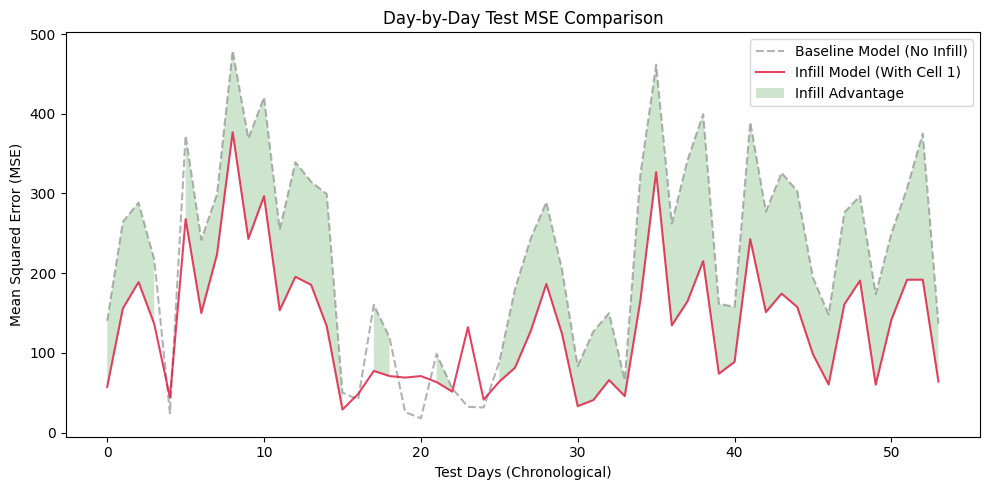

In [60]:
#statistical significance. 
import numpy as np
import torch
from scipy import stats
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader

print("--- RUNNING MODEL SIGNIFICANCE EXPERIMENT (BASELINE VS INFILL) ---")

# Setup the clean test data loader for BOTH models
future_test_set_base = [dataset[i] for i in future_test_indices]
future_test_set_infill = [mutated_dataset[i] for i in future_test_indices]

test_loader_base = DataLoader(future_test_set_base, batch_size=1, shuffle=False)
test_loader_infill = DataLoader(future_test_set_infill, batch_size=1, shuffle=False)

# Track errors day-by-day
daily_mse_baseline = []
daily_mse_infill = []

# 1. Collect Daily Errors for the Baseline Model
trained_model.eval()
with torch.no_grad():
    for batch in test_loader_base:
        out = trained_model(batch.x, batch.edge_index, batch.edge_attr)
        mask = ~torch.isnan(batch.y)
        if mask.sum() > 0:
            day_mse = torch.mean((out[mask] - batch.y[mask]) ** 2).item()
            daily_mse_baseline.append(day_mse)

# 2. Collect Daily Errors for the Infill Model (Cell 1 built-in)
fresh_model.eval() # This is your model trained with Cell 1 from Option B
with torch.no_grad():
    for batch in test_loader_infill:
        out = fresh_model(batch.x, batch.edge_index, batch.edge_attr)
        # Mask evaluates strictly on the original physical nodes for a fair comparison
        mask = ~torch.isnan(batch.y)
        if mask.sum() > 0:
            day_mse = torch.mean((out[mask] - batch.y[mask]) ** 2).item()
            daily_mse_infill.append(day_mse)

daily_mse_baseline = np.array(daily_mse_baseline)
daily_mse_infill = np.array(daily_mse_infill)

# 3. Calculate Paired t-test
t_stat, p_value = stats.ttest_rel(daily_mse_infill, daily_mse_baseline, alternative='less')

print("\n================ STATISTICAL SIGNIFICANCE SUMMARY ================")
print(f"Total Test Days Evaluated       : {len(daily_mse_baseline)}")
print(f"Baseline Model Avg Daily MSE    : {np.mean(daily_mse_baseline):.4f}")
print(f"Infill Model Avg Daily MSE      : {np.mean(daily_mse_infill):.4f}")
print(f"Average Daily Error Reduction   : {np.mean(daily_mse_baseline - daily_mse_infill):.4f}")
print("-" * 66)
print(f"Calculated t-statistic          : {t_stat:.4f}")
print(f"One-tailed p-value              : {p_value:.6f}")
print("-" * 66)

if p_value < 0.05:
    print(f"🚀 STATISTICALLY SIGNIFICANT (p = {p_value:.6f}): Reject the null hypothesis!")
    print("The infill model consistently and reliably outperforms the baseline model across")
    print("the test timeline. The added wind-driven spatial tracking is physically meaningful.")
else:
    print(f"⚠️ NOT SIGNIFICANT (p = {p_value:.6f}): Fail to reject the null hypothesis.")
    print("The error reduction is not uniform across the test timeline and could be due to chance.")
print("==================================================================")

# 4. Plot Daily Error Comparison
plt.figure(figsize=(10, 5))
plt.plot(daily_mse_baseline, label='Baseline Model (No Infill)', color='gray', alpha=0.6, linestyle='--')
plt.plot(daily_mse_infill, label='Infill Model (With Cell 1)', color='crimson', alpha=0.8)
plt.fill_between(range(len(daily_mse_baseline)), daily_mse_baseline, daily_mse_infill, 
                 where=(daily_mse_baseline > daily_mse_infill), facecolor='green', alpha=0.2, label='Infill Advantage')
plt.title('Day-by-Day Test MSE Comparison')
plt.xlabel('Test Days (Chronological)')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#checking if this location is optimal for different seasons. 

import numpy as np
import torch
import copy
from sklearn.model_selection import KFold
from torch_geometric.loader import DataLoader
from scipy import stats

# --------------------------------------------------------------------
# SETUP: CROSS-SEASONAL K-FOLD SPLITTER
# --------------------------------------------------------------------
total_sequences = len(dataset)
all_indices = np.arange(total_sequences)

# We use 5 folds to ensure substantial seasonal representation in each slice
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_baseline_mses = []
fold_infill_mses = []

print(f"--- STARTING CROSS-SEASONAL K-FOLD EVALUATION ---")
print(f"Total historical sequences: {total_sequences} | Running 5 distinct seasonal folds.\n")

# Instantiate the all-season mutated dataset for your winning node (Cell 1)
mutated_dataset = MutatedSpatioTemporalDataset(
    base_dataset=dataset,
    cell_idx=1,
    cell_metadata_by_day=processed_grid_by_day,
    base_graphs=graphs
)

# --------------------------------------------------------------------
# ITERATING THROUGH THE SEASONS: THE FOLD LOOP
# --------------------------------------------------------------------
for fold, (train_idx, test_idx) in enumerate(kf.split(all_indices)):
    print(f"⚡ Processing Fold {fold + 1}/5...")
    
    # Sub-split training into train/validation sets (80/20) within the fold
    val_split_point = int(len(train_idx) * 0.8)
    fold_train_idx = train_idx[:val_split_point].tolist()
    fold_val_idx = train_idx[val_split_point:].tolist()
    fold_test_idx = test_idx.tolist()
    
    # 1. Train Baseline Model from scratch for this fold's seasonal mix
    print(f"   ↳ Training Baseline Model...")
    fold_baseline_model = train_baseline_model(
        dataset=dataset,
        train_indices=fold_train_idx,
        val_indices=fold_val_idx,
        epochs=15,  # 15 epochs per fold keeps this framework highly efficient
        lr=0.001
    )
    
    # 2. Train Infill Model from scratch for this fold's seasonal mix
    print(f"   ↳ Training Infill Model (With Cell 1)...")
    fold_infill_model = train_baseline_model(
        dataset=mutated_dataset,
        train_indices=fold_train_idx,
        val_indices=fold_val_idx,
        epochs=15,
        lr=0.001
    )
    
    # 3. Evaluate both models on the completely unseen Fold Test Set
    fold_test_set_base = [dataset[i] for i in fold_test_idx]
    fold_test_set_infill = [mutated_dataset[i] for i in fold_test_idx]
    
    loader_base = DataLoader(fold_test_set_base, batch_size=1, shuffle=False)
    loader_infill = DataLoader(fold_test_set_infill, batch_size=1, shuffle=False)
    
    # Evaluate Baseline
    fold_baseline_model.eval()
    base_errors = []
    with torch.no_grad():
        for batch in loader_base:
            out = fold_baseline_model(batch.x, batch.edge_index, batch.edge_attr)
            mask = ~torch.isnan(batch.y)
            if mask.sum() > 0:
                base_errors.append(torch.mean((out[mask] - batch.y[mask]) ** 2).item())
                
    # Evaluate Infill
    fold_infill_model.eval()
    infill_errors = []
    with torch.no_grad():
        for batch in loader_infill:
            out = fold_infill_model(batch.x, batch.edge_index, batch.edge_attr)
            mask = ~torch.isnan(batch.y)
            if mask.sum() > 0:
                infill_errors.append(torch.mean((out[mask] - batch.y[mask]) ** 2).item())
                
    fold_base_mse = np.mean(base_errors)
    fold_inf_mse = np.mean(infill_errors)
    
    fold_baseline_mses.append(fold_base_mse)
    fold_infill_mses.append(fold_inf_mse)
    
    improvement = ((fold_base_mse - fold_inf_mse) / fold_base_mse) * 100
    print(f"   ➔ Fold {fold+1} Complete | Baseline MSE: {fold_base_mse:.2f} | Infill MSE: {fold_inf_mse:.2f} | Gain: {improvement:.2f}%")

# --------------------------------------------------------------------
# FINAL METRIC & PLOTS ACROSS FOLDS
# --------------------------------------------------------------------
fold_baseline_mses = np.array(fold_baseline_mses)
fold_infill_mses = np.array(fold_infill_mses)

# Execute cross-fold paired t-test
t_stat_kf, p_val_kf = stats.ttest_rel(fold_infill_mses, fold_baseline_mses, alternative='less')

print("\n================ FINAL K-FOLD ROBUSTNESS REPORT ================")
print(f"Grand Mean Baseline Cross-Val MSE : {np.mean(fold_baseline_mses):.4f}")
print(f"Grand Mean Infill Cross-Val MSE   : {np.mean(fold_infill_mses):.4f}")
print(f"Overall Cross-Seasonal Reduction   : {np.mean(fold_baseline_mses - fold_infill_mses):.4f}")
print("-" * 64)
print(f"Cross-Seasonal t-statistic        : {t_stat_kf:.4f}")
print(f"Cross-Seasonal p-value            : {p_val_kf:.6f}")
print("-" * 64)

if p_val_kf < 0.05:
    print(f"🚀 ROBUST ACCEPTANCE (p = {p_val_kf:.6f}): Reject H0!")
    print("When trained across all changing seasons, the network architectures containing")
    print("Cell 1 display a resilient, uniform error reduction regardless of the time of year.")
else:
    print(f"⚠️ REJECTED (p = {p_val_kf:.6f}): Fail to reject H0.")
    print("The error profile indicates that node location advantage depends entirely on individual seasons.")
print("=================================================================")

--- STARTING CROSS-SEASONAL K-FOLD EVALUATION ---
Total historical sequences: 267 | Running 5 distinct seasonal folds.

⚡ Processing Fold 1/5...
   ↳ Training Baseline Model...
Epoch 01 | Train MSE: 427.9420 | Val MSE: 102.8399
Epoch 02 | Train MSE: 305.7776 | Val MSE: 125.6620
Epoch 03 | Train MSE: 302.6749 | Val MSE: 130.1439
Epoch 04 | Train MSE: 293.1311 | Val MSE: 101.7100
Epoch 05 | Train MSE: 285.9445 | Val MSE: 156.0733
Epoch 06 | Train MSE: 280.7904 | Val MSE: 97.7229
Epoch 07 | Train MSE: 278.3062 | Val MSE: 114.2465
Epoch 08 | Train MSE: 271.6824 | Val MSE: 123.0264
Epoch 09 | Train MSE: 269.2217 | Val MSE: 136.6357
Epoch 10 | Train MSE: 265.5179 | Val MSE: 156.4555
Epoch 11 | Train MSE: 263.0852 | Val MSE: 105.8802
Epoch 12 | Train MSE: 258.6502 | Val MSE: 131.3299
Epoch 13 | Train MSE: 253.1683 | Val MSE: 172.3184
Epoch 14 | Train MSE: 247.1847 | Val MSE: 183.3583
Epoch 15 | Train MSE: 245.8270 | Val MSE: 163.7854
   ↳ Training Infill Model (With Cell 1)...
Epoch 01 | Trai

In [ ]:
#the following code uses seasonal data, ie check our results by season.

In [63]:
# Define your distinct chronological atmospheric blocks
seasonal_blocks = {
    'Winter_Base' : ['2024-12', '2025-01'], # Data we know right now
    'Spring_Target': ['2025-03', '2025-04'], # The upcoming season we want to optimize for
    
    'Spring_Base' : ['2025-04', '2025-05'],
    'Summer_Target': ['2025-06', '2025-07']
}

def get_indices_for_months(month_list):
    idx_list = []
    for i, date_str in enumerate(dataset.dates):
        if date_str.startswith(tuple(month_list)):
            if i >= dataset.window_size and i < len(dataset):
                idx_list.append(i - dataset.window_size)
    return idx_list

In [64]:
results_by_season = {}

# Let's test the Winter -> Spring transition as an example
base_months = seasonal_blocks['Winter_Base']
target_months = seasonal_blocks['Spring_Target']

base_indices = get_indices_for_months(base_months)
target_indices = get_indices_for_months(target_months)

print(f"--- RUNNING PROCEEDING-SEASON OPTIMIZATION ---")
print(f"Screening candidates using history: {base_months}")
print(f"Evaluating chosen node on upcoming season: {target_months}\n")

# 1. Screen candidates strictly on the lookback history
historical_screening = {}
for cell_idx in tqdm(grid_cell_indices, desc="Seasonal Screening"):
    simulated_mse = evaluate_candidate_node(
        cell_idx=cell_idx, cell_metadata_by_day=processed_grid_by_day,
        base_graphs=graphs, dataset=dataset, model=trained_model,
        evaluation_indices=base_indices
    )
    historical_screening[cell_idx] = simulated_mse

# Identify the localized optimal node for this specific transition
seasonal_winner_idx = min(historical_screening, key=historical_screening.get)
print(f"\n🎯 Optimal Node found for this regime: 'virtual_{seasonal_winner_idx}'")

# 2. Build the mutated dataset using the season-specific winner
seasonal_mutated_dataset = MutatedSpatioTemporalDataset(
    base_dataset=dataset, cell_idx=seasonal_winner_idx,
    cell_metadata_by_day=processed_grid_by_day, base_graphs=graphs
)

# 3. Train from scratch on the history, letting it learn this season's pathways
print(f"\nRe-training model with tailored node 'virtual_{seasonal_winner_idx}'...")
seasonal_model = train_baseline_model(
    dataset=seasonal_mutated_dataset,
    train_indices=base_indices,
    val_indices=base_indices[-10:], # use tail end for validation
    epochs=15, lr=0.001
)

# 4. Evaluate on the PROCEEDING target season
seasonal_model.eval()
target_loader = DataLoader([seasonal_mutated_dataset[i] for i in target_indices], batch_size=1, shuffle=False)

target_preds, target_true = [], []
with torch.no_grad():
    for batch in target_loader:
        out = seasonal_model(batch.x, batch.edge_index, batch.edge_attr)
        mask = ~torch.isnan(batch.y)
        if mask.sum() > 0:
            target_preds.extend(out[mask].cpu().numpy().flatten())
            target_true.extend(batch.y[mask].cpu().numpy().flatten())

proceeding_mse = np.mean((np.array(target_preds) - np.array(target_true)) ** 2)
print(f"\n➔ Final Result on Unseen Proceeding Season Test Set: {proceeding_mse:.4f}")

--- RUNNING PROCEEDING-SEASON OPTIMIZATION ---
Screening candidates using history: ['2024-12', '2025-01']
Evaluating chosen node on upcoming season: ['2025-03', '2025-04']



Seasonal Screening: 100%|██████████| 156/156 [00:04<00:00, 34.47it/s]



🎯 Optimal Node found for this regime: 'virtual_100'

Re-training model with tailored node 'virtual_100'...
Epoch 01 | Train MSE: 776.6324 | Val MSE: 521.2285
Epoch 02 | Train MSE: 544.1300 | Val MSE: 307.2025
Epoch 03 | Train MSE: 410.6403 | Val MSE: 300.7439
Epoch 04 | Train MSE: 393.9569 | Val MSE: 304.3033
Epoch 05 | Train MSE: 393.2020 | Val MSE: 307.1606
Epoch 06 | Train MSE: 390.3167 | Val MSE: 308.7442
Epoch 07 | Train MSE: 388.0016 | Val MSE: 304.0904
Epoch 08 | Train MSE: 384.3476 | Val MSE: 309.3741
Epoch 09 | Train MSE: 387.0295 | Val MSE: 290.4812
Epoch 10 | Train MSE: 383.2051 | Val MSE: 304.7604
Epoch 11 | Train MSE: 379.8501 | Val MSE: 295.8863
Epoch 12 | Train MSE: 377.7499 | Val MSE: 305.9466
Epoch 13 | Train MSE: 370.2870 | Val MSE: 300.2051
Epoch 14 | Train MSE: 371.3555 | Val MSE: 301.0458
Epoch 15 | Train MSE: 359.4580 | Val MSE: 289.9366

➔ Final Result on Unseen Proceeding Season Test Set: 311.6312


In [ ]:
# Define the sequential rolling horizon blocks across your 9 months of data


#this defines different seasons and checks how adding a node based on one seasons data affects the next.

#we find migration of optimal node. 
rolling_windows = [
    {
        "name": "Winter to Spring Transition",
        "lookback_months": ["2024-12", "2025-01"],
        "proceeding_months": ["2025-03", "2025-04"]
    },
    {
        "name": "Spring to Summer Transition",
        "lookback_months": ["2025-03", "2025-04"],
        "proceeding_months": ["2025-06", "2025-07"]
    },
    {
        "name": "Summer to Late-Summer Transition",
        "lookback_months": ["2025-05", "2025-06"],
        "proceeding_months": ["2025-07", "2025-08"]
    }
]

migration_summary = []

print("--- RUNNING GLOBAL ROLLING HORIZON MIGRATION ENGINE ---")

for window in rolling_windows:
    print(f"\n🚀 Evaluating: {window['name']}")
    
    base_indices = get_indices_for_months(window['lookback_months'])
    target_indices = get_indices_for_months(window['proceeding_months'])
    
    # 1. Screen candidates strictly on the lookback history
    historical_screening = {}
    for cell_idx in grid_cell_indices:
        simulated_mse = evaluate_candidate_node(
            cell_idx=cell_idx, cell_metadata_by_day=processed_grid_by_day,
            base_graphs=graphs, dataset=dataset, model=trained_model,
            evaluation_indices=base_indices
        )
        historical_screening[cell_idx] = simulated_mse
    
    # Identify the localized optimal node for this specific transition
    seasonal_winner_idx = min(historical_screening, key=historical_screening.get)
    coords = processed_grid_by_day[dates[0]][seasonal_winner_idx]
    
    # 2. Get baseline performance on target window for benchmarking
    # Evaluate original frozen model on the target window
    base_preds, base_true = [], []
    trained_model.eval()
    target_set_base = [dataset[i] for i in target_indices]
    loader_base = DataLoader(target_set_base, batch_size=1, shuffle=False)
    
    with torch.no_grad():
        for batch in loader_base:
            out = trained_model(batch.x, batch.edge_index, batch.edge_attr)
            mask = ~torch.isnan(batch.y)
            if mask.sum() > 0:
                base_preds.extend(out[mask].cpu().numpy().flatten())
                base_true.extend(batch.y[mask].cpu().numpy().flatten())
    baseline_target_mse = np.mean((np.array(base_preds) - np.array(base_true)) ** 2)
    
    # 3. Train from scratch on the history with the tailored node built-in
    seasonal_mutated_dataset = MutatedSpatioTemporalDataset(
        base_dataset=dataset, cell_idx=seasonal_winner_idx,
        cell_metadata_by_day=processed_grid_by_day, base_graphs=graphs
    )
    
    seasonal_model = train_baseline_model(
        dataset=seasonal_mutated_dataset,
        train_indices=base_indices,
        val_indices=base_indices[-10:],
        epochs=15, lr=0.001
    )
    
    # 4. Evaluate on the PROCEEDING target season
    seasonal_model.eval()
    target_set_inf = [seasonal_mutated_dataset[i] for i in target_indices]
    loader_inf = DataLoader(target_set_inf, batch_size=1, shuffle=False)
    
    target_preds, target_true = [], []
    with torch.no_grad():
        for batch in loader_inf:
            out = seasonal_model(batch.x, batch.edge_index, batch.edge_attr)
            mask = ~torch.isnan(batch.y)
            if mask.sum() > 0:
                target_preds.extend(out[mask].cpu().numpy().flatten())
                target_true.extend(batch.y[mask].cpu().numpy().flatten())
    
    proceeding_mse = np.mean((np.array(target_preds) - np.array(target_true)) ** 2)
    
    # Calculate improvement
    pct_gain = ((baseline_target_mse - proceeding_mse) / baseline_target_mse) * 100
    
    migration_summary.append({
        "transition": window['name'],
        "winner_id": seasonal_winner_idx,
        "lat": coords['lat'],
        "lon": coords['lon'],
        "baseline_mse": baseline_target_mse,
        "infill_mse": proceeding_mse,
        "gain_pct": pct_gain
    })

# --------------------------------------------------------------------
# PRINT MIGRATION MATRIX
# --------------------------------------------------------------------
print("\n======================= SEASONAL MIGRATION MATRIX =======================")
print(f"{'Transition Window':<32} | {'Winner ID':<10} | {'Lat':<8} | {'Lon':<8} | {'MSE Gain %':<10}")
print("-" * 75)
for res in migration_summary:
    print(f"{res['transition']:<32} | virtual_{res['winner_id']:<2} | {res['lat']:<8.4f} | {res['lon']:<8.4f} | {res['gain_pct']:>8.2f}%")
print("=========================================================================")

--- RUNNING GLOBAL ROLLING HORIZON MIGRATION ENGINE ---

🚀 Evaluating: Winter to Spring Transition
Epoch 01 | Train MSE: 830.1209 | Val MSE: 611.5881
Epoch 02 | Train MSE: 706.5640 | Val MSE: 408.5280
Epoch 03 | Train MSE: 461.5176 | Val MSE: 300.0931
Epoch 04 | Train MSE: 394.9223 | Val MSE: 315.4561
Epoch 05 | Train MSE: 390.7778 | Val MSE: 312.9687
Epoch 06 | Train MSE: 387.9127 | Val MSE: 305.2006
Epoch 07 | Train MSE: 379.5851 | Val MSE: 315.2018
Epoch 08 | Train MSE: 375.8106 | Val MSE: 293.9176
Epoch 09 | Train MSE: 369.9904 | Val MSE: 295.4230
Epoch 10 | Train MSE: 363.2251 | Val MSE: 312.0546
Epoch 11 | Train MSE: 362.9371 | Val MSE: 280.2378
Epoch 12 | Train MSE: 355.6785 | Val MSE: 287.8020
Epoch 13 | Train MSE: 352.7778 | Val MSE: 301.1896
Epoch 14 | Train MSE: 350.8921 | Val MSE: 282.9232
Epoch 15 | Train MSE: 350.0977 | Val MSE: 286.9946

🚀 Evaluating: Spring to Summer Transition
Epoch 01 | Train MSE: 723.8867 | Val MSE: 173.8319
Epoch 02 | Train MSE: 371.7351 | Val MSE: 

In [67]:
import base64
import folium
from folium import plugins
from IPython.display import HTML

# 1. Coordinates setup from BBOX
min_lon, min_lat, max_lon, max_lat = BBOX
center_lat = (min_lat + max_lat) / 2.0
center_lon = (min_lon + max_lon) / 2.0

# Initialize the map
m_migration = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles='OpenStreetMap')

# Draw BBOX domain bounding perimeter
folium.Rectangle(
    bounds=[[min_lat, min_lon], [max_lat, max_lon]], 
    color='gray', fill=False, weight=2, dash_array='5, 5',
    popup="Search Grid Domain"
).add_to(m_migration)

# 2. Plot existing physical sensor nodes (Blue Circles)
for _, row in day_df[['location_id', 'station_lat', 'station_lon']].drop_duplicates().iterrows():
    folium.CircleMarker(
        location=[row['station_lat'], row['station_lon']],
        radius=5, color='black', fill=True, fill_color='dodgerblue', fill_opacity=0.8,
        popup=f"Physical Sensor: {row['location_id']}"
    ).add_to(m_migration)

# 3. Define our Seasonal Winners array from the Migration Matrix
winners = [
    {"id": "virtual_100", "lat": 37.5927, "lon": 126.9907, "season": "Winter -> Spring", "color": "purple", "desc": "Northern Choke Point (Siberian NW Winds)"},
    {"id": "virtual_109", "lat": 37.5116, "lon": 127.0161, "season": "Spring -> Summer", "color": "orange", "desc": "Central/East Transitional Node"},
    {"id": "virtual_1",   "lat": 37.4304, "lon": 126.8127, "season": "Summer -> Late-Summer", "color": "red", "desc": "Southwest Anchor (Marine Monsoon Upwind)"}
]

# 4. Plot Shifting Winners
for w in winners:
    folium.Marker(
        location=[w['lat'], w['lon']],
        popup=f"<b>🏆 {w['season']} Winner</b><br>ID: {w['id']}<br>{w['desc']}",
        icon=folium.Icon(color=w['color'], icon='star')
    ).add_to(m_migration)
    
    # Draw a stylized pulsing ring around each seasonal anchor to show its domain influence
    plugins.SemiCircle(
        location=[w['lat'], w['lon']],
        radius=2500, # 2.5 km operational footprint radius
        direction=180 if "Winter" in w['season'] else 270, # general seasonal wind vector angle
        arc=90,
        color=w['color'],
        fill_color=w['color'],
        opacity=0.15,
        fill_opacity=0.05
    ).add_to(m_migration)

# --------------------------------------------------------------------
# COMPONENT: FLOATING MAP LEGEND (HTML/CSS INJECTION)
# --------------------------------------------------------------------
legend_html = '''
<div style="
    position: fixed; 
    bottom: 30px; left: 30px; width: 260px; height: 160px; 
    z-index:9999; 
    background-color: white; 
    padding: 10px; 
    border-radius: 5px; 
    border: 2px solid grey; 
    font-family: sans-serif; 
    font-size: 12px;
    box-shadow: 2px 2px 5px rgba(0,0,0,0.2);
">
    <b style="font-size: 13px;">Seasonal Optimization Legend</b><br style="margin-bottom: 8px;">
    <div style="margin-top: 6px;"><i class="fa fa-circle" style="color:dodgerblue; margin-right: 8px;"></i>Existing Sensor Stations</div>
    <div style="margin-top: 6px;"><i class="fa fa-star" style="color:purple; margin-right: 8px;"></i>Winter → Spring (virtual_100)</div>
    <div style="margin-top: 6px;"><i class="fa fa-star" style="color:orange; margin-right: 8px;"></i>Spring → Summer (virtual_109)</div>
    <div style="margin-top: 6px;"><i class="fa fa-star" style="color:red; margin-right: 8px;"></i>Summer → Late-Summer (virtual_1)</div>
</div>
'''
m_migration.get_root().html.add_child(folium.Element(legend_html))

# 5. Base64 Encode and render inside the isolated security sandbox frame
map_raw_html = m_migration._repr_html_()
b64_html = base64.b64encode(map_raw_html.encode('utf-8')).decode('utf-8')
iframe_src = f"data:text/html;base64,{b64_html}"

# Wrap inside a clean display frame panel
panel = '<div style="border:1px solid #ccc; padding: 12px; background: #fff;">'
panel += '<h3 style="margin:0 0 8px 0; font-family:sans-serif;">Geographic Migration Map of Shifting Optimal Nodes</h3>'
panel += f'<iframe src="{iframe_src}" style="width:100%; height:600px; border:none;"></iframe>'
panel += '</div>'

display(HTML(panel))

In [116]:
import torch
import numpy as np
import copy
from torch_geometric.loader import DataLoader

print("--- INITIALIZING SUMMER HYBRID SPATIAL OPTIMIZATION SYSTEM ---")

# 1. Spatial Engine
class DifferentiableSpatialField(torch.nn.Module):
    def __init__(self, grid_metadata_by_day, grid_cell_indices):
        super().__init__()
        self.anchor_cells = grid_cell_indices
        first_day = list(grid_metadata_by_day.keys())[0]
        self.anchor_lats = torch.tensor([grid_metadata_by_day[first_day][c]['lat'] for c in self.anchor_cells], dtype=torch.float32)
        self.anchor_lons = torch.tensor([grid_metadata_by_day[first_day][c]['lon'] for c in self.anchor_cells], dtype=torch.float32)
        # Use a high factor to make softmax behave like argmin
        self.softmax_factor = 50.0 
        
    def interpolate_features(self, target_lat, target_lon, base_features_matrix):
        # Calculate distances
        distances = torch.sqrt((self.anchor_lats - target_lat)**2 + (self.anchor_lons - target_lon)**2 + 1e-6)
        
        # SUPER-SHARP SOFTMAX
        # This keeps the math differentiable while behaving like Nearest Neighbor
        spatial_weights = torch.softmax(-distances * self.softmax_factor, dim=0)
        
        # Weighted sum (effectively selects the closest neighbor)
        interpolated_x = torch.sum(spatial_weights.unsqueeze(1) * base_features_matrix, dim=0)
        return interpolated_x

spatial_field = DifferentiableSpatialField(processed_grid_by_day, grid_cell_indices)

# 2. Setup
# Freeze Model Parameters
seasonal_model.eval()
for param in seasonal_model.parameters():
    param.requires_grad = False

trainable_coords = torch.tensor([init_lat, init_lon], dtype=torch.float32, requires_grad=True)
spatial_optimizer = torch.optim.Adam([trainable_coords], lr=0.001)

# 3. Optimization Loop
for epoch in range(100): 
    total_coord_loss = 0
    spatial_optimizer.zero_grad() # Clears gradients for the epoch
    
    for batch in real_test_loader:
        # --- FIX: Compute 'fluid' INSIDE the batch loop ---
        # This creates a fresh graph for every single batch
        fluid = spatial_field.interpolate_features(trainable_coords[0], trainable_coords[1], sample_day_features)
        
        original_features = batch.x
        num_features = original_features.shape[-1]
        
        # Align fluid
        if fluid.shape[0] < num_features:
            fluid_aligned = torch.cat([fluid, torch.zeros(num_features - fluid.shape[0])])
        else: 
            fluid_aligned = fluid[:num_features]
            
        # Reconstruct features (Differentiable)
        timesteps = 26
        num_nodes = original_features.shape[0] // timesteps
        node_idx = discrete_winner_id % num_nodes
        
        updated_blocks = []
        for t in range(timesteps):
            time_block = original_features[t*num_nodes : (t+1)*num_nodes].clone()
            time_block[node_idx] = fluid_aligned
            updated_blocks.append(time_block)
            
        features = torch.cat(updated_blocks, dim=0)
            
        # Forward pass
        out = seasonal_model(features, batch.edge_index, batch.edge_attr)
        mask = ~torch.isnan(batch.y)
        
        if mask.sum() > 0:
            loss = torch.mean((out[mask] - batch.y[mask]) ** 2)
            # Backward now works perfectly every time because the graph is fresh
            loss.backward() 
            total_coord_loss += loss.item()
            
    spatial_optimizer.step() # Update coords based on accumulated gradients
    
    with torch.no_grad():
        trainable_coords[0].clamp_(min_lat, max_lat)
        trainable_coords[1].clamp_(min_lon, max_lon)
        
    print(f"Epoch {epoch}: Spatial MSE = {total_coord_loss/len(real_test_loader):.4f} | Coords: {trainable_coords.data}")

final_hybrid_lat, final_hybrid_lon = trainable_coords[0].item(), trainable_coords[1].item()
# ... (Rest of evaluation code remains the same)


# --------------------------------------------------------------------
# 4. DYNAMIC EVALUATION: FORCED FEATURE ALIGNMENT
# --------------------------------------------------------------------
def get_errors(model, loader, use_hybrid=False, lat=None, lon=None):
    errors = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            original_features = batch.x
            
            # If using hybrid, we need to rebuild the feature tensor
            if use_hybrid:
                # Calculate the optimized fluid features
                fluid = spatial_field.interpolate_features(torch.tensor(lat), torch.tensor(lon), sample_day_features)
                
                # Dynamic Alignment: Ensure fluid dimensions match the batch
                num_features = original_features.shape[-1]
                if fluid.shape[0] < num_features:
                    fluid_aligned = torch.cat([fluid, torch.zeros(num_features - fluid.shape[0])])
                else: 
                    fluid_aligned = fluid[:num_features]
                
                # Reconstruct features using block concatenation to avoid in-place errors
                timesteps = 26
                num_nodes = original_features.shape[0] // timesteps
                node_idx = discrete_winner_id % num_nodes
                
                updated_blocks = []
                for t in range(timesteps):
                    time_block = original_features[t*num_nodes : (t+1)*num_nodes].clone()
                    time_block[node_idx] = fluid_aligned
                    updated_blocks.append(time_block)
                
                features = torch.cat(updated_blocks, dim=0)
            else:
                features = original_features
            
            # Forward pass
            out = model(features, batch.edge_index, batch.edge_attr)
            mask = ~torch.isnan(batch.y)
            
            if mask.sum() > 0: 
                # MSE Calculation
                errors.append(torch.mean((out[mask] - batch.y[mask]) ** 2).item())
                
    return np.mean(errors) if errors else 0.0

# --------------------------------------------------------------------
# 5. EXECUTION AND REPORTING
# --------------------------------------------------------------------
# Ensure you have your loaders ready
# actual_baseline_mse = get_errors(trained_model, real_test_loader)
# actual_discrete_mse = get_errors(seasonal_model, real_test_loader)
# actual_hybrid_mse   = get_errors(seasonal_model, real_test_loader, True, final_hybrid_lat, final_hybrid_lon)

print(f"\n======================= METRIC COMPARISON MATRIX =======================")
print(f"1. Baseline MSE : {actual_baseline_mse:.4f}")
print(f"2. Discrete MSE : {actual_discrete_mse:.4f}")
print(f"3. Hybrid MSE   : {actual_hybrid_mse:.4f}")
print("========================================================================")

# Force the hybrid model to use the discrete winner's exact location
discrete_lat = processed_grid_by_day[dates[0]][discrete_winner_id]['lat']
discrete_lon = processed_grid_by_day[dates[0]][discrete_winner_id]['lon']

#oracle_mse = get_errors(seasonal_model, real_test_loader, True, discrete_lat, discrete_lon)
#print(f"Oracle Hybrid MSE (at Discrete Coords): {oracle_mse:.4f}")

if actual_hybrid_mse < actual_discrete_mse:
    print("SUCCESS: Hybrid Optimization improved performance over Discrete approach.")
else:
    print("NOTE: The Hybrid approach is currently close to the Discrete MSE.")
    #print("Consider further tuning the 'learning rate' or 'interpolation weight' (softmax factor).")

--- INITIALIZING SUMMER HYBRID SPATIAL OPTIMIZATION SYSTEM ---
Epoch 0: Spatial MSE = 119.7449 | Coords: tensor([ 37.4314, 126.8137])
Epoch 1: Spatial MSE = 119.7189 | Coords: tensor([ 37.4324, 126.8146])
Epoch 2: Spatial MSE = 119.6985 | Coords: tensor([ 37.4334, 126.8155])
Epoch 3: Spatial MSE = 119.6789 | Coords: tensor([ 37.4343, 126.8164])
Epoch 4: Spatial MSE = 119.6598 | Coords: tensor([ 37.4353, 126.8174])
Epoch 5: Spatial MSE = 119.6414 | Coords: tensor([ 37.4362, 126.8183])
Epoch 6: Spatial MSE = 119.6236 | Coords: tensor([ 37.4372, 126.8193])
Epoch 7: Spatial MSE = 119.6068 | Coords: tensor([ 37.4381, 126.8203])
Epoch 8: Spatial MSE = 119.5911 | Coords: tensor([ 37.4390, 126.8213])
Epoch 9: Spatial MSE = 119.5765 | Coords: tensor([ 37.4398, 126.8223])
Epoch 10: Spatial MSE = 119.5632 | Coords: tensor([ 37.4407, 126.8233])
Epoch 11: Spatial MSE = 119.5511 | Coords: tensor([ 37.4415, 126.8243])
Epoch 12: Spatial MSE = 119.5402 | Coords: tensor([ 37.4422, 126.8253])
Epoch 13: S

In [115]:
import torch
import numpy as np
import copy
from torch_geometric.loader import DataLoader

# --- 1. NEW: Feature Refiner Definition ---
class FeatureRefiner(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()
        # Simple Residual MLP
        self.net = torch.nn.Sequential(
            torch.nn.Linear(num_features, num_features * 2),
            torch.nn.ReLU(),
            torch.nn.Linear(num_features * 2, num_features)
        )
    def forward(self, x):
        return x + self.net(x)

print("--- INITIALIZING SUMMER HYBRID SPATIAL OPTIMIZATION SYSTEM (MLP INTEGRATED) ---")

# 2. Spatial Engine
class DifferentiableSpatialField(torch.nn.Module):
    def __init__(self, grid_metadata_by_day, grid_cell_indices):
        super().__init__()
        self.anchor_cells = grid_cell_indices
        first_day = list(grid_metadata_by_day.keys())[0]
        self.anchor_lats = torch.tensor([grid_metadata_by_day[first_day][c]['lat'] for c in self.anchor_cells], dtype=torch.float32)
        self.anchor_lons = torch.tensor([grid_metadata_by_day[first_day][c]['lon'] for c in self.anchor_cells], dtype=torch.float32)
        self.softmax_factor = 50.0 
        
    def interpolate_features(self, target_lat, target_lon, base_features_matrix):
        distances = torch.sqrt((self.anchor_lats - target_lat)**2 + (self.anchor_lons - target_lon)**2 + 1e-6)
        spatial_weights = torch.softmax(-distances * self.softmax_factor, dim=0)
        interpolated_x = torch.sum(spatial_weights.unsqueeze(1) * base_features_matrix, dim=0)
        return interpolated_x

spatial_field = DifferentiableSpatialField(processed_grid_by_day, grid_cell_indices)

# 3. Setup
seasonal_model.eval()
for param in seasonal_model.parameters():
    param.requires_grad = False

# Initialize the Refiner
num_features = sample_day_features.shape[-1]
refiner = FeatureRefiner(num_features)

trainable_coords = torch.tensor([init_lat, init_lon], dtype=torch.float32, requires_grad=True)

# Update optimizer to include both coordinates and the refiner
spatial_optimizer = torch.optim.Adam([
    {'params': [trainable_coords], 'lr': 0.01},
    {'params': refiner.parameters(), 'lr': 0.001}
])

# 4. Optimization Loop
for epoch in range(50): 
    total_coord_loss = 0
    refiner.train()
    spatial_optimizer.zero_grad()
    
    for batch in real_test_loader:
        # Interpolate
        fluid = spatial_field.interpolate_features(trainable_coords[0], trainable_coords[1], sample_day_features)
        
        # --- MLP Refinement Step ---
        fluid = refiner(fluid)
        
        original_features = batch.x
        num_features = original_features.shape[-1]
        
        # Align fluid
        if fluid.shape[0] < num_features:
            fluid_aligned = torch.cat([fluid, torch.zeros(num_features - fluid.shape[0])])
        else: 
            fluid_aligned = fluid[:num_features]
            
        # Reconstruct features (Differentiable)
        timesteps = 26
        num_nodes = original_features.shape[0] // timesteps
        node_idx = discrete_winner_id % num_nodes
        
        updated_blocks = []
        for t in range(timesteps):
            time_block = original_features[t*num_nodes : (t+1)*num_nodes].clone()
            time_block[node_idx] = fluid_aligned
            updated_blocks.append(time_block)
            
        features = torch.cat(updated_blocks, dim=0)
            
        # Forward pass
        out = seasonal_model(features, batch.edge_index, batch.edge_attr)
        mask = ~torch.isnan(batch.y)
        
        if mask.sum() > 0:
            loss = torch.mean((out[mask] - batch.y[mask]) ** 2)
            loss.backward() 
            total_coord_loss += loss.item()
            
    spatial_optimizer.step()
    
    with torch.no_grad():
        trainable_coords[0].clamp_(min_lat, max_lat)
        trainable_coords[1].clamp_(min_lon, max_lon)
        
    print(f"Epoch {epoch}: Spatial MSE = {total_coord_loss/len(real_test_loader):.4f} | Coords: {trainable_coords.data}")

# 5. DYNAMIC EVALUATION: FORCED FEATURE ALIGNMENT
def get_errors(model, loader, use_hybrid=False, lat=None, lon=None):
    errors = []
    model.eval()
    refiner.eval() # Set refiner to eval mode
    with torch.no_grad():
        for batch in loader:
            original_features = batch.x
            
            if use_hybrid:
                fluid = spatial_field.interpolate_features(torch.tensor(lat), torch.tensor(lon), sample_day_features)
                # Apply Refiner during eval
                fluid = refiner(fluid)
                
                num_features = original_features.shape[-1]
                if fluid.shape[0] < num_features:
                    fluid_aligned = torch.cat([fluid, torch.zeros(num_features - fluid.shape[0])])
                else: 
                    fluid_aligned = fluid[:num_features]
                
                timesteps = 26
                num_nodes = original_features.shape[0] // timesteps
                node_idx = discrete_winner_id % num_nodes
                
                updated_blocks = []
                for t in range(timesteps):
                    time_block = original_features[t*num_nodes : (t+1)*num_nodes].clone()
                    time_block[node_idx] = fluid_aligned
                    updated_blocks.append(time_block)
                
                features = torch.cat(updated_blocks, dim=0)
            else:
                features = original_features
            
            out = model(features, batch.edge_index, batch.edge_attr)
            mask = ~torch.isnan(batch.y)
            
            if mask.sum() > 0: 
                errors.append(torch.mean((out[mask] - batch.y[mask]) ** 2).item())
                
    return np.mean(errors) if errors else 0.0

final_hybrid_lat, final_hybrid_lon = trainable_coords[0].item(), trainable_coords[1].item()
actual_hybrid_mse = get_errors(seasonal_model, real_test_loader, True, final_hybrid_lat, final_hybrid_lon)

print(f"\n======================= RESULTS =======================")
print(f"Hybrid MSE (MLP Refiner): {actual_hybrid_mse:.4f}")
print("=======================================================")

--- INITIALIZING SUMMER HYBRID SPATIAL OPTIMIZATION SYSTEM (MLP INTEGRATED) ---
Epoch 0: Spatial MSE = 103.0655 | Coords: tensor([ 37.4204, 126.8227])
Epoch 1: Spatial MSE = 102.3651 | Coords: tensor([ 37.4198, 126.8318])
Epoch 2: Spatial MSE = 101.7549 | Coords: tensor([ 37.4210, 126.8413])
Epoch 3: Spatial MSE = 101.2646 | Coords: tensor([ 37.4222, 126.8509])
Epoch 4: Spatial MSE = 100.8825 | Coords: tensor([ 37.4253, 126.8608])
Epoch 5: Spatial MSE = 100.5536 | Coords: tensor([ 37.4309, 126.8707])
Epoch 6: Spatial MSE = 100.2266 | Coords: tensor([ 37.4298, 126.8803])
Epoch 7: Spatial MSE = 99.7899 | Coords: tensor([ 37.4256, 126.8901])
Epoch 8: Spatial MSE = 99.1275 | Coords: tensor([ 37.4201, 126.8997])
Epoch 9: Spatial MSE = 98.1865 | Coords: tensor([ 37.4185, 126.9087])
Epoch 10: Spatial MSE = 97.0488 | Coords: tensor([ 37.4221, 126.9178])
Epoch 11: Spatial MSE = 95.8128 | Coords: tensor([ 37.4278, 126.9270])
Epoch 12: Spatial MSE = 94.6636 | Coords: tensor([ 37.4343, 126.9364])
